## 2.1 Генерация данных

In [1]:
import numpy as np
import pandas as pd
import scipy
import math
from copy import deepcopy
from itertools import product
from scipy.stats import t, chi2, f, norm, poisson, binom, uniform, expon, logistic, multivariate_normal
import matplotlib.pyplot as plt
import seaborn
import sklearn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, KFold
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                              RandomForestRegressor, GradientBoostingRegressor)
from sklearn.naive_bayes import CategoricalNB, GaussianNB
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor, NearestNeighbors
from sklearn.metrics import (confusion_matrix, RocCurveDisplay, precision_score,
                             recall_score, accuracy_score, f1_score, make_scorer)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn import metrics
import statsmodels.api as sm
import networkx as nx
import bnlearn
import doubleml as dml
from catboost import CatBoostClassifier, CatBoostRegressor


In [2]:
np.random.seed(123)
n = 30000

In [3]:
income = np.exp(norm.rvs(size = n, loc = 11.1, scale = 0.5))

In [4]:
age = norm.rvs(size = n, loc = 35, scale = 10)
age[age >= 70] = 70
age[age <= 18] = 18
age = np.round(age)

In [5]:
urban_area = np.random.binomial(n = 1, p = 0.7, size = n)

In [6]:
family_size = np.random.choice(a = [1, 2, 3, 4, 5],
                               size = n,
                               p = [0.20, 0.35, 0.25, 0.15, 0.05])

In [7]:
online_preference_raw = norm.rvs(size = n, loc = 0, scale = 1)
online_preference = logistic.cdf(online_preference_raw)

In [8]:
log_income = np.log(income)
income_z = (log_income - 11.1) / 0.5
age_center = (age - 35) / 10

free_trial_banner_index = (-0.75
                           + 4 * (0.15 * income_z
                                  + 0.08 * urban_area
                                  - 0.07 * age_center
                                  - 0.06 * (family_size - 2.5)))
free_trial_banner_prob = norm.cdf(free_trial_banner_index)
free_trial_banner = np.random.binomial(n = 1, p = free_trial_banner_prob, size = n)

In [9]:
np.mean(free_trial_banner)

np.float64(0.33886666666666665)

In [10]:
u = uniform.rvs(size = n)
premium_index = (-0.55
                 + 2.8 * (online_preference - 0.5)
                 + 0.22 * income_z
                 + 0.12 * urban_area
                 + 0.10 * (family_size - 2.5)
                 + 0.85 * urban_area * (family_size >= 3)
                 + 0.75 * (income_z > 0.7) * urban_area
                 - 0.75 * (income_z < -0.6) * (1 - urban_area)
                 - 0.65 * ((age - 32) / 13) ** 2
                 + 0.50 * ((age >= 26) & (age <= 38)) * urban_area
                 + 0.45 * ((family_size >= 4) & (income_z > -0.2)))

premium_segment = ((urban_area == 1) & (family_size >= 3)).astype(float)
free_trial_banner1 = 1
premium1_prob = logistic.cdf(premium_index + 0.75 * free_trial_banner1
                             + 0.30 * premium_segment
                             + 0.20 * (income_z > 0.5))
premium1 = (u <= premium1_prob).astype(int)

free_trial_banner0 = 0
premium0_prob = logistic.cdf(premium_index + 0.75 * free_trial_banner0
                             + 0.30 * premium_segment * free_trial_banner0
                             + 0.20 * (income_z > 0.5) * free_trial_banner0)
premium0 = (u <= premium0_prob).astype(int)

premium_subscription = premium1 * free_trial_banner + premium0 * (1 - free_trial_banner)

In [11]:
np.mean(premium1)

np.float64(0.6041)

In [12]:
np.mean(premium0)

np.float64(0.437)

In [13]:
ind_type = np.empty(n, dtype = 'U25')
ind_type[(premium1 == 1) & (premium0 == 1)] = 'Always taker'
ind_type[(premium1 == 0) & (premium0 == 0)] = 'Never taker'
ind_type[premium1 > premium0] = 'Complier'
ind_type[premium1 < premium0] = 'Denier'
pd.Series(ind_type).value_counts()

Always taker    13110
Never taker     11877
Complier         5013
Name: count, dtype: int64

In [14]:
premium_subscription = premium1 * free_trial_banner + premium0 * (1 - free_trial_banner)
np.mean(premium_subscription)

np.float64(0.4940333333333333)

In [15]:
print(pd.DataFrame(data    = [np.corrcoef(premium_subscription, online_preference)[0, 1],
                              np.corrcoef(premium_subscription, free_trial_banner)[0, 1]],
                   index   = ['Corr(premium_subscription, online_preference)',
                              'Corr(premium_subscription, free_trial_banner)'],
                   columns = ['Оценка']))

                                                 Оценка
Corr(premium_subscription, online_preference)  0.219636
Corr(premium_subscription, free_trial_banner)  0.225888


In [16]:
error0 = t.rvs(size = n, df = 10) * 1600
error1 = t.rvs(size = n, df = 8) * 2200

In [17]:
base_spending = (4800
                 + 1250 * income_z
                 + 850 * urban_area
                 + 650 * (family_size - 2)
                 - 280 * (age_center ** 2)
                 + 650 * urban_area * (family_size - 2)
                 + 1400 * np.maximum(income_z, 0) * urban_area
                 + 650 * ((age >= 25) & (age <= 40)) * urban_area)
g0_obs = base_spending
g0_unobs = 1.25 * (1600 * (online_preference - 0.5) + 800 * online_preference_raw)
g0 = g0_obs + g0_unobs

In [18]:
treatment_effect_structural = (3900
                               + 950 * urban_area
                               + 800 * (family_size - 2)
                               + 900 * np.maximum(income_z, 0)
                               + 700 * online_preference
                               + 700 * urban_area * (family_size >= 3)
                               + 700 * ((age >= 25) & (age <= 40)) * urban_area
                               + 500 * (income_z > 0.8))
g1_obs = base_spending + treatment_effect_structural
g1_unobs = 2.5 * (2200 * (online_preference - 0.5) + 800 * online_preference_raw)
g1 = g1_obs + g1_unobs

In [19]:
monthly_spending0 = g0 + error0
monthly_spending1 = g1 + error1
monthly_spending0[monthly_spending0 < 1] = 1
monthly_spending1[monthly_spending1 < 1] = 1

monthly_spending = monthly_spending1 * premium_subscription + monthly_spending0 * (1 - premium_subscription)

In [20]:
df = pd.DataFrame({
    "monthly_spending": monthly_spending,
    "premium_subscription": premium_subscription,
    "income": income,
    "age": age,
    "urban_area": urban_area,
    "family_size": family_size,
    "free_trial_banner": free_trial_banner
})
df = df.loc[0:n, :]

## 2.2 Описательные статистики

In [21]:
df.describe().round(2)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,9952.12,0.49,75206.02,35.21,0.70,2.49,0.34
std,6539.10,0.50,40050.14,9.61,0.46,1.12,0.47
min,1.00,0.00,9890.31,18.00,0.00,1.00,0.00
25%,4757.59,0.00,47285.73,28.00,0.00,2.00,0.00
50%,8478.69,0.00,66396.19,35.00,1.00,2.00,0.00
75%,14642.53,1.00,92902.68,42.00,1.00,3.00,1.00
max,36871.00,1.00,505876.81,70.00,1.00,5.00,1.00


In [22]:
binary_check = pd.DataFrame({
    'count_ones': [int(np.sum(premium_subscription)),
                   int(np.sum(free_trial_banner)),
                   int(np.sum(urban_area))],
    'share_ones': [np.mean(premium_subscription),
                   np.mean(free_trial_banner),
                   np.mean(urban_area)],
    'requirement_min': [0.10, 0.10, 0.10],
    'requirement_max': [0.90, 0.90, 0.90]
}, index = ['premium_subscription', 'free_trial_banner', 'urban_area'])

binary_check['passes_requirement'] = binary_check['share_ones'].between(
    binary_check['requirement_min'],
    binary_check['requirement_max']
)
binary_check

,count_ones,share_ones,requirement_min,requirement_max,passes_requirement
premium_subscription,14821,0.494033,0.1,0.9,True
free_trial_banner,10166,0.338867,0.1,0.9,True
urban_area,21044,0.701467,0.1,0.9,True


In [23]:
corr_table = pd.DataFrame(data = [np.corrcoef(premium_subscription, online_preference)[0, 1],
                                        np.corrcoef(premium_subscription, free_trial_banner)[0, 1]],
                          index = ['Corr(premium_subscription, online_preference)',
                                     'Corr(premium_subscription, free_trial_banner)'],
                          columns = ['estimate'])
corr_table

,estimate
"Corr(premium_subscription, online_preference)",0.219636
"Corr(premium_subscription, free_trial_banner)",0.225888


In [24]:
TE = monthly_spending1 - monthly_spending0
ATE = np.mean(TE)
LATE = np.mean(TE[ind_type == "Complier"])
CATE = g1 - g0
ATE_naive = np.mean(monthly_spending[premium_subscription == 1]) - np.mean(monthly_spending[premium_subscription == 0])

effect_table = pd.DataFrame({'estimate': [ATE, LATE, np.mean(CATE), ATE_naive]
                }, index = ['ATE', 'LATE', 'mean(CATE)', 'ATE_naive'])
effect_table.round(2)

,estimate
ATE,6292.96
LATE,6280.32
mean(CATE),6279.19
ATE_naive,9760.32


In [25]:
df.corr().round(3)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
monthly_spending,1.000,0.746,0.432,-0.095,0.302,0.350,0.200
premium_subscription,0.746,1.000,0.229,-0.137,0.213,0.146,0.226
income,0.432,0.229,1.000,-0.002,-0.002,-0.002,0.370
age,-0.095,-0.137,-0.002,1.000,-0.008,-0.002,-0.161
urban_area,0.302,0.213,-0.002,-0.008,1.000,-0.006,0.090
family_size,0.350,0.146,-0.002,-0.002,-0.006,1.000,-0.176
free_trial_banner,0.200,0.226,0.370,-0.161,0.090,-0.176,1.000


## 2.3 Разбиение на выборки

In [26]:
df_train, df_test = train_test_split(df, test_size=0.25, random_state=123)

## 2.4 Дополнительный анализ

In [27]:
df_full = df.copy()
df_full['income_z'] = income_z
df_full['age_center'] = age_center
df_full['online_preference_raw'] = online_preference_raw
df_full['online_preference'] = online_preference
df_full['free_trial_banner_index'] = free_trial_banner_index
df_full['free_trial_banner_prob'] = free_trial_banner_prob
df_full['premium_index'] = premium_index
df_full['premium_segment'] = premium_segment
df_full['premium1_prob'] = premium1_prob
df_full['premium0_prob'] = premium0_prob
df_full['premium1'] = premium1
df_full['premium0'] = premium0
df_full['ind_type'] = ind_type
df_full['error0'] = error0
df_full['error1'] = error1
df_full['base_spending'] = base_spending
df_full['g0_obs'] = g0_obs
df_full['g0_unobs'] = g0_unobs
df_full['g0'] = g0
df_full['treatment_effect_structural'] = treatment_effect_structural
df_full['g1_obs'] = g1_obs
df_full['g1_unobs'] = g1_unobs
df_full['g1'] = g1
df_full['monthly_spending0'] = monthly_spending0
df_full['monthly_spending1'] = monthly_spending1
df_full['TE'] = monthly_spending1 - monthly_spending0
df_full['CATE'] = g1 - g0

df_full_train = df_full.loc[df_train.index]
df_full_test = df_full.loc[df_test.index]

df.to_csv("data/df.csv", index=False)
df_train.to_csv("data/df_train.csv", index=False)
df_test.to_csv("data/df_test.csv", index=False)
df_full.to_csv("data/df_full.csv", index=False)
df_full_train.to_csv("data/df_full_train.csv", index=False)
df_full_test.to_csv("data/df_full_test.csv", index=False)

In [28]:
generation_diagnostic = pd.DataFrame({
    'metric': ['share_premium_subscription', 'share_free_trial_banner', 'share_urban_area',
               'Corr(D, Z)', 'Corr(D, online_preference)',
               'P(D=1 | Z=0)', 'P(D=1 | Z=1)',
               'ATE', 'LATE', 'ATE_naive'],
    'value': [np.mean(premium_subscription), np.mean(free_trial_banner), np.mean(urban_area),
              np.corrcoef(premium_subscription, free_trial_banner)[0, 1],
              np.corrcoef(premium_subscription, online_preference)[0, 1],
              np.mean(premium_subscription[free_trial_banner == 0]),
              np.mean(premium_subscription[free_trial_banner == 1]),
              ATE, LATE, ATE_naive]
})
generation_diagnostic.round(3)

,metric,value
0,share_premium_subscription,0.494
1,share_free_trial_banner,0.339
2,share_urban_area,0.701
3,"Corr(D, Z)",0.226
4,"Corr(D, online_preference)",0.220
5,P(D=1 | Z=0),0.413
6,P(D=1 | Z=1),0.652
7,ATE,6292.960
8,LATE,6280.319
9,ATE_naive,9760.320


## 3.1 Отбор признаков

In [29]:
df = pd.read_csv("data/df.csv")
df_train = pd.read_csv("data/df_train.csv")
df_test = pd.read_csv("data/df_test.csv")
df.head()

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
0,11721.117830,1,38452.719412,24.0,1,2,0
1,10911.269377,1,108953.092363,27.0,1,2,1
2,8642.447791,0,76228.390348,53.0,1,1,0
3,1.000000,0,31158.820400,52.0,1,1,0
4,7228.550018,0,49548.133698,48.0,0,3,0


In [30]:
feature_cols = ['income', 'age', 'urban_area', 'family_size', 'free_trial_banner']
target_col = 'premium_subscription'

features = df.loc[:, feature_cols]
target = np.squeeze(df.loc[:, [target_col]])

In [31]:
features_train = df_train.loc[:, feature_cols]
features_test = df_test.loc[:, feature_cols]
target_train = np.squeeze(df_train.loc[:, [target_col]])
target_test = np.squeeze(df_test.loc[:, [target_col]])

n_train = len(target_train)
n_test = len(target_test)
print({'n_train': n_train, 'n_test': n_test})

{'n_train': 22500, 'n_test': 7500}


In [32]:
features_train_raw = features_train.copy()
features_test_raw = features_test.copy()

## 3.2 Тюнинг гиперпараметров (accuracy)

In [33]:
cv_all = 3

classification_initial_models = {
    'Наивный Байес': GaussianNB(var_smoothing = 1e-9),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier(n_neighbors = 35, weights = 'distance'))
    ]),
    'Случайный лес': RandomForestClassifier(max_depth = 8,
                                            max_features = 'sqrt',
                                            n_estimators = 100,
                                            max_samples = 500,
                                            random_state = 777,
                                            criterion = 'entropy'),
    'Градиентный бустинг': GradientBoostingClassifier(loss = 'log_loss',
                                                      n_estimators = 80,
                                                      learning_rate = 0.08,
                                                      max_depth = 3,
                                                      random_state = 123),
    'Логит': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(C = 0.1,
                                     penalty = 'l2',
                                     solver = 'lbfgs',
                                     fit_intercept = True,
                                     max_iter = 1000))
    ])
}

classification_param_grids = {
    'Наивный Байес': {'var_smoothing': [1e-10, 1e-9, 1e-8, 1e-7]},
    'KNN': {'model__n_neighbors': [15, 35, 75],
            'model__weights': ['uniform', 'distance']},
    'Случайный лес': {'max_depth': [5, 8, 12],
                      'max_features': ['sqrt', None],
                      'n_estimators': [80, 120]},
    'Градиентный бустинг': {'max_depth': [2, 3],
                            'learning_rate': [0.05, 0.1, 0.2],
                            'n_estimators': [60, 100]},
    'Логит': {'model__C': [0.01, 0.1, 1, 10],
              'model__penalty': ['l2']}
}

In [34]:
all_classification_rows = []
all_classification_models = {}
all_classification_best_params = {}

for model_name, model in classification_initial_models.items():
    model.fit(features_train_raw, target_train)
    acc_train_initial = model.score(features_train_raw, target_train)
    acc_test_initial = model.score(features_test_raw, target_test)
    acc_cv_initial = np.mean(cross_val_score(model, features_train_raw, target_train,
                                             cv = cv_all, scoring = 'accuracy'))

    grid_acc = GridSearchCV(estimator = classification_initial_models[model_name],
                            param_grid = classification_param_grids[model_name],
                            scoring = 'accuracy',
                            cv = cv_all,
                            n_jobs = 1)
    grid_acc.fit(features_train_raw, target_train)
    tuned_model_acc = grid_acc.best_estimator_
    all_classification_models[model_name] = tuned_model_acc
    all_classification_best_params[model_name] = grid_acc.best_params_

    acc_test_tuned = tuned_model_acc.score(features_test_raw, target_test)
    prob_tuned = tuned_model_acc.predict_proba(features_test_raw)[:, 1]

    all_classification_rows.append({
        'модель': model_name,
        'исходные гиперпараметры': str(model.get_params()),
        'подобранные гиперпараметры': str(grid_acc.best_params_),
        'train-ACC до тюнинга': acc_train_initial,
        'CV-ACC до тюнинга': acc_cv_initial,
        'CV-ACC после тюнинга': grid_acc.best_score_,
        'test-ACC до тюнинга': acc_test_initial,
        'test-ACC после тюнинга': acc_test_tuned,
        'test-AUC после тюнинга': metrics.roc_auc_score(target_test, prob_tuned),
        'test-F1 после тюнинга': f1_score(target_test, tuned_model_acc.predict(features_test_raw))
    })

classification_all_summary = pd.DataFrame(all_classification_rows).set_index('модель')
classification_all_summary.sort_values('test-AUC после тюнинга', ascending = False)

,исходные гиперпараметры,подобранные гиперпараметры,train-ACC до тюнинга,CV-ACC до тюнинга,CV-ACC после тюнинга,test-ACC до тюнинга,test-ACC после тюнинга,test-AUC после тюнинга,test-F1 после тюнинга
модель,,,,,,,,,
Градиентный бустинг,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.700000,0.696178,0.695956,0.686933,0.688133,0.763548,0.675274
Случайный лес,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...","{'max_depth': 8, 'max_features': None, 'n_esti...",0.698444,0.693956,0.693911,0.686667,0.685333,0.760400,0.670667
KNN,"{'memory': None, 'steps': [('scaler', Standard...","{'model__n_neighbors': 75, 'model__weights': '...",1.000000,0.668844,0.693200,0.673600,0.684533,0.758051,0.672027
Наивный Байес,"{'priors': None, 'var_smoothing': 1e-09}",{'var_smoothing': 1e-10},0.647200,0.646844,0.673911,0.637467,0.670133,0.741878,0.636390
Логит,"{'memory': None, 'steps': [('scaler', Standard...","{'model__C': 0.01, 'model__penalty': 'l2'}",0.669822,0.669422,0.669422,0.665467,0.665467,0.729304,0.657006


In [35]:
logit2 = all_classification_models['Логит']
rf2 = all_classification_models['Случайный лес']
gb2 = all_classification_models['Градиентный бустинг']

best_logit_params = all_classification_best_params['Логит']
best_rf_params = all_classification_best_params['Случайный лес']
best_gb_params = all_classification_best_params['Градиентный бустинг']

ACC_test_logit2 = classification_all_summary.loc['Логит', 'test-ACC после тюнинга']
ACC_test_rf2 = classification_all_summary.loc['Случайный лес', 'test-ACC после тюнинга']
ACC_test_gb2 = classification_all_summary.loc['Градиентный бустинг', 'test-ACC после тюнинга']
ACC_CV_logit2 = classification_all_summary.loc['Логит', 'CV-ACC после тюнинга']
ACC_CV_rf2 = classification_all_summary.loc['Случайный лес', 'CV-ACC после тюнинга']
ACC_CV_gb2 = classification_all_summary.loc['Градиентный бустинг', 'CV-ACC после тюнинга']

## 3.2* OOB для случайного леса

In [36]:
hyperparameters_rf = classification_param_grids['Случайный лес']

oob_rows = []
for max_depth in hyperparameters_rf['max_depth']:
    for max_features in hyperparameters_rf['max_features']:
        for n_estimators in hyperparameters_rf['n_estimators']:
            rf_oob_i = RandomForestClassifier(max_depth = max_depth,
                                              max_features = max_features,
                                              n_estimators = n_estimators,
                                              max_samples = 500,
                                              random_state = 777,
                                              criterion = 'entropy',
                                              oob_score = True)
            rf_oob_i.fit(features_train_raw, target_train)
            oob_rows.append({
                'max_depth': max_depth,
                'max_features': max_features,
                'n_estimators': n_estimators,
                'OOB error': 1 - rf_oob_i.oob_score_,
                'test-ACC': rf_oob_i.score(features_test_raw, target_test)
            })

oob_grid = pd.DataFrame(oob_rows).sort_values('OOB error').reset_index(drop = True)
oob_grid

,max_depth,max_features,n_estimators,OOB error,test-ACC
0,12,None,120,0.305689,0.684267
1,12,sqrt,120,0.306222,0.690933
2,8,None,120,0.306356,0.685333
3,12,None,80,0.306933,0.685200
4,12,sqrt,80,0.307200,0.689067
5,8,sqrt,80,0.307422,0.686000
6,8,None,80,0.307733,0.686133
7,5,None,120,0.307867,0.689200
8,8,sqrt,120,0.308089,0.688000
9,5,sqrt,80,0.308489,0.687867


In [37]:
best_rf_oob_params = oob_grid.loc[0, ['max_depth', 'max_features', 'n_estimators']].to_dict()

rf_oob_best = RandomForestClassifier(max_depth = int(best_rf_oob_params['max_depth']),
                                     max_features = best_rf_oob_params['max_features'],
                                     n_estimators = int(best_rf_oob_params['n_estimators']),
                                     max_samples = 500,
                                     random_state = 777,
                                     criterion = 'entropy',
                                     oob_score = True)
rf_oob_best.fit(features_train_raw, target_train)
ACC_test_rf_oob = rf_oob_best.score(features_test_raw, target_test)
ACC_CV_rf_oob = np.mean(cross_val_score(RandomForestClassifier(max_depth = int(best_rf_oob_params['max_depth']),
                                                               max_features = best_rf_oob_params['max_features'],
                                                               n_estimators = int(best_rf_oob_params['n_estimators']),
                                                               max_samples = 500,
                                                               random_state = 777,
                                                               criterion = 'entropy'),
                                        features_train_raw, target_train, cv = 5, scoring = 'accuracy'))

rf_cv_mask = (oob_grid['max_depth'] == best_rf_params['max_depth']) & (oob_grid['n_estimators'] == best_rf_params['n_estimators'])
if best_rf_params['max_features'] is None:
    rf_cv_mask = rf_cv_mask & oob_grid['max_features'].isna()
else:
    rf_cv_mask = rf_cv_mask & oob_grid['max_features'].eq(best_rf_params['max_features'])
oob_error_rf_cv = oob_grid.loc[rf_cv_mask, 'OOB error'].iloc[0]

rf_oob_comparison = pd.DataFrame({
    'подобранные гиперпараметры': [str(best_rf_params), str(best_rf_oob_params)],
    'OOB error': [oob_error_rf_cv, 1 - rf_oob_best.oob_score_],
    'CV accuracy': [ACC_CV_rf2, ACC_CV_rf_oob],
    'test accuracy': [ACC_test_rf2, ACC_test_rf_oob]
}, index = ['RF tuned by CV', 'RF tuned by OOB'])
rf_oob_comparison

,подобранные гиперпараметры,OOB error,CV accuracy,test accuracy
RF tuned by CV,"{'max_depth': 8, 'max_features': None, 'n_esti...",0.306356,0.693911,0.685333
RF tuned by OOB,"{'max_depth': 12, 'max_features': None, 'n_est...",0.305689,0.692844,0.684267


## 3.3 Тюнинг по F1 и custom utility

In [38]:
classification_f1_rows = []
classification_f1_models = {}

for model_name, model in classification_initial_models.items():
    model.fit(features_train_raw, target_train)
    f1_cv_initial = np.mean(cross_val_score(model, features_train_raw, target_train,
                                            cv = cv_all, scoring = 'f1'))
    f1_test_initial = f1_score(target_test, model.predict(features_test_raw))

    grid_f1 = GridSearchCV(estimator = classification_initial_models[model_name],
                           param_grid = classification_param_grids[model_name],
                           scoring = 'f1',
                           cv = cv_all,
                           n_jobs = 1)
    grid_f1.fit(features_train_raw, target_train)
    tuned_model_f1 = grid_f1.best_estimator_
    classification_f1_models[model_name] = tuned_model_f1

    classification_f1_rows.append({
        'модель': model_name,
        'исходные гиперпараметры': str(model.get_params()),
        'подобранные гиперпараметры (F1)': str(grid_f1.best_params_),
        'CV-F1 до тюнинга': f1_cv_initial,
        'CV-F1 после тюнинга': grid_f1.best_score_,
        'test-F1 до тюнинга': f1_test_initial,
        'test-F1 после тюнинга': f1_score(target_test, tuned_model_f1.predict(features_test_raw))
    })

f1_summary = pd.DataFrame(classification_f1_rows).set_index('модель')
f1_summary.sort_values('test-F1 после тюнинга', ascending = False)

,исходные гиперпараметры,подобранные гиперпараметры (F1),CV-F1 до тюнинга,CV-F1 после тюнинга,test-F1 до тюнинга,test-F1 после тюнинга
модель,,,,,,
Случайный лес,"{'bootstrap': True, 'ccp_alpha': 0.0, 'class_w...","{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.682855,0.683389,0.672884,0.678249
Градиентный бустинг,"{'ccp_alpha': 0.0, 'criterion': 'friedman_mse'...","{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.682644,0.685536,0.670410,0.675274
KNN,"{'memory': None, 'steps': [('scaler', Standard...","{'model__n_neighbors': 75, 'model__weights': '...",0.661694,0.683132,0.666303,0.672027
Логит,"{'memory': None, 'steps': [('scaler', Standard...","{'model__C': 0.1, 'model__penalty': 'l2'}",0.660456,0.660456,0.657100,0.657100
Наивный Байес,"{'priors': None, 'var_smoothing': 1e-09}",{'var_smoothing': 1e-10},0.574388,0.642151,0.559533,0.636390


In [39]:
def custom_weighted_utility(y_true, y_pred):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    N = y_true.size
    return (2 * TP + 1 * TN - 1 * FP - 3 * FN) / N


def custom_utility_scorer(estimator, X, y):
    prediction = estimator.predict(X)
    return custom_weighted_utility(y, prediction)

In [40]:
custom_utility_rows = []
custom_utility_models = {}

for model_name, model in classification_initial_models.items():
    grid_custom = GridSearchCV(estimator = classification_initial_models[model_name],
                               param_grid = classification_param_grids[model_name],
                               scoring = custom_utility_scorer,
                               cv = cv_all,
                               n_jobs = 1)
    grid_custom.fit(features_train_raw, target_train)
    tuned_model_custom = grid_custom.best_estimator_
    custom_utility_models[model_name] = tuned_model_custom

    f1_model = classification_f1_models[model_name]
    pred_f1 = f1_model.predict(features_test_raw)
    pred_custom = tuned_model_custom.predict(features_test_raw)
    prob_custom = tuned_model_custom.predict_proba(features_test_raw)[:, 1]

    custom_utility_rows.append({
        'модель': model_name,
        'лучшие параметры по F1': str(f1_summary.loc[model_name, 'подобранные гиперпараметры (F1)']),
        'test-F1 после F1-тюнинга': f1_summary.loc[model_name, 'test-F1 после тюнинга'],
        'custom utility на test после F1-тюнинга': custom_weighted_utility(target_test, pred_f1),
        'лучшие параметры по custom utility': str(grid_custom.best_params_),
        'CV custom utility': grid_custom.best_score_,
        'custom utility на test': custom_weighted_utility(target_test, pred_custom),
        'test-ACC после custom utility': accuracy_score(target_test, pred_custom),
        'test-F1 после custom utility': f1_score(target_test, pred_custom),
        'test-AUC после custom utility': metrics.roc_auc_score(target_test, prob_custom)
    })

custom_utility_summary = pd.DataFrame(custom_utility_rows).set_index('модель')
custom_utility_summary.sort_values('custom utility на test', ascending = False)

,лучшие параметры по F1,test-F1 после F1-тюнинга,custom utility на test после F1-тюнинга,лучшие параметры по custom utility,CV custom utility,custom utility на test,test-ACC после custom utility,test-F1 после custom utility,test-AUC после custom utility
модель,,,,,,,,,
Градиентный бустинг,"{'learning_rate': 0.1, 'max_depth': 2, 'n_esti...",0.675274,0.358400,"{'learning_rate': 0.05, 'max_depth': 2, 'n_est...",0.405422,0.378133,0.684800,0.678804,0.758260
Случайный лес,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.678249,0.373733,"{'max_depth': 5, 'max_features': 'sqrt', 'n_es...",0.393289,0.373733,0.686400,0.678249,0.760122
KNN,"{'model__n_neighbors': 75, 'model__weights': '...",0.672027,0.348000,"{'model__n_neighbors': 75, 'model__weights': '...",0.391333,0.348000,0.684533,0.672027,0.758051
Логит,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.657100,0.301867,"{'model__C': 0.1, 'model__penalty': 'l2'}",0.316178,0.301867,0.665467,0.657100,0.729300
Наивный Байес,{'var_smoothing': 1e-10},0.636390,0.215600,{'var_smoothing': 1e-10},0.238356,0.215600,0.670133,0.636390,0.741878


In [41]:
best_custom_model = custom_utility_summary['custom utility на test'].idxmax()
best_f1_model = f1_summary['test-F1 после тюнинга'].idxmax()

print('Лучшая модель по F1:', best_f1_model)
print('Лучшая модель по custom utility:', best_custom_model)
print('Совпадает ли лучшая модель:', best_f1_model == best_custom_model)

Лучшая модель по F1: Случайный лес
Лучшая модель по custom utility: Градиентный бустинг
Совпадает ли лучшая модель: False


## 3.4 ROC-кривые

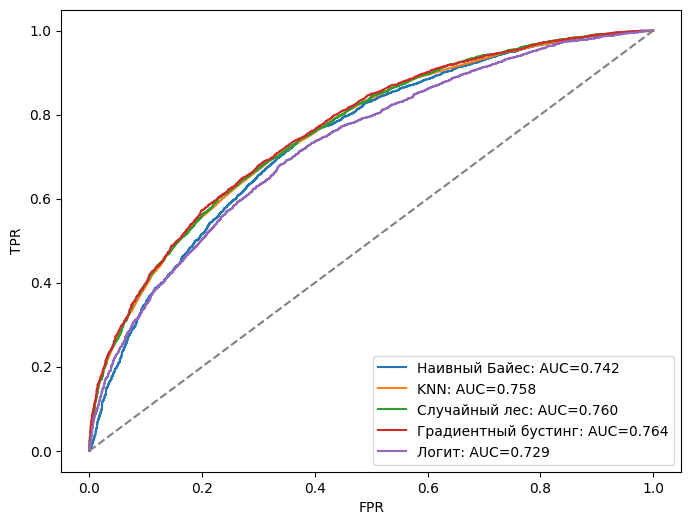

,AUC
модель,
Градиентный бустинг,0.763548
Случайный лес,0.760400
KNN,0.758051
Наивный Байес,0.741878
Логит,0.729304


In [42]:
plt.figure(figsize = (8, 6))
classification_auc_rows = []
for model_name, model in all_classification_models.items():
    prob = model.predict_proba(features_test_raw)[:, 1]
    fpr, tpr, _ = metrics.roc_curve(target_test, prob)
    auc_value = metrics.roc_auc_score(target_test, prob)
    classification_auc_rows.append({'модель': model_name, 'AUC': auc_value})
    plt.plot(fpr, tpr, label = f'{model_name}: AUC={auc_value:.3f}')
plt.plot([0, 1], [0, 1], '--', color = 'gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

classification_auc_table = pd.DataFrame(classification_auc_rows).set_index('модель').sort_values('AUC', ascending = False)
classification_auc_table

In [43]:
logit_AUC = classification_auc_table.loc['Логит', 'AUC']
rf_AUC = classification_auc_table.loc['Случайный лес', 'AUC']
gb_AUC = classification_auc_table.loc['Градиентный бустинг', 'AUC']
classification_auc_table

,AUC
модель,
Градиентный бустинг,0.763548
Случайный лес,0.760400
KNN,0.758051
Наивный Байес,0.741878
Логит,0.729304


## 3.5 Матрица ошибок

In [44]:
confusion_rows = []
for model_name, model in all_classification_models.items():
    prediction = model.predict(features_test_raw)
    TN, FP, FN, TP = confusion_matrix(target_test, prediction).ravel()
    confusion_rows.append({'модель': model_name,
                           'TN': TN,
                           'FP': FP,
                           'FN': FN,
                           'TP': TP})
confusion_table = pd.DataFrame(confusion_rows).set_index('модель')
confusion_table

,TN,FP,FN,TP
модель,,,,
Наивный Байес,2861,924,1550,2165
KNN,2710,1075,1291,2424
Случайный лес,2737,1048,1312,2403
Градиентный бустинг,2729,1056,1283,2432
Логит,2588,1197,1312,2403


## 3.6 Пороги классификации

In [45]:
thresholds = [0.3, 0.5, 0.7]
threshold_rows = []
for model_name, model in all_classification_models.items():
    prob = model.predict_proba(features_test_raw)[:, 1]
    for c in thresholds:
        pred = (prob >= c).astype(int)
        threshold_rows.append([model_name,
                               c,
                               accuracy_score(target_test, pred),
                               precision_score(target_test, pred),
                               recall_score(target_test, pred)])
thr_table = pd.DataFrame(threshold_rows, columns = ['модель', 'threshold', 'ACC', 'Precision', 'Recall'])
thr_table

,модель,threshold,ACC,Precision,Recall
0,Наивный Байес,0.3,0.622667,0.574684,0.916555
1,Наивный Байес,0.5,0.670133,0.700874,0.582773
2,Наивный Байес,0.7,0.592667,0.794643,0.239569
3,KNN,0.3,0.635333,0.584922,0.908479
4,KNN,0.5,0.684533,0.692769,0.652490
5,KNN,0.7,0.637467,0.806650,0.352624
6,Случайный лес,0.3,0.628133,0.577321,0.930552
7,Случайный лес,0.5,0.685333,0.696320,0.646837
8,Случайный лес,0.7,0.623733,0.830496,0.302019
9,Градиентный бустинг,0.3,0.636800,0.584919,0.918708


## 3.7 Функция прибыли

In [46]:
prices = pd.Series({'TP': 0,
                    'TN': 100,
                    'FP': 0,
                    'FN': -500})
prices

TP      0
TN    100
FP      0
FN   -500
dtype: int64

In [47]:
def profits_thresholds(model, features, target, thresholds, prices):
    prob = model.predict_proba(features)[:, 1]
    n_threshold = thresholds.size
    profits = np.zeros(n_threshold)
    for i in range(0, n_threshold):
        prediction_i = (prob >= thresholds[i]).astype(int)
        TN, FP, FN, TP = confusion_matrix(target, prediction_i).ravel()
        predictions_i = pd.Series([TP, TN, FP, FN], index = ['TP', 'TN', 'FP', 'FN'])
        profits[i] = np.sum(prices * predictions_i)
    return profits

In [48]:
def best_threshold_profit(model, features_train, target_train, features_test, target_test, prices):
    prob_train = model.predict_proba(features_train)[:, 1]
    thresholds = np.unique(np.sort(prob_train))
    profits_train = profits_thresholds(model, features_train, target_train, thresholds, prices)
    c_opt = thresholds[np.argmax(profits_train)]
    prob_test = model.predict_proba(features_test)[:, 1]
    pred_test = (prob_test >= c_opt).astype(int)
    TN, FP, FN, TP = confusion_matrix(target_test, pred_test).ravel()
    predictions = pd.Series([TP, TN, FP, FN], index = ['TP', 'TN', 'FP', 'FN'])
    profit_test = np.sum(prices * predictions)
    return c_opt, profit_test

In [49]:
profit_rows = []
for model_name, model in all_classification_models.items():
    c_opt, profit_test = best_threshold_profit(model,
                                               features_train_raw, target_train,
                                               features_test_raw, target_test,
                                               prices)
    profit_rows.append({'модель': model_name,
                        'оптимальный порог': c_opt,
                        'прибыль на тесте': profit_test})

profit_table = pd.DataFrame(profit_rows).set_index('модель').sort_values('прибыль на тесте', ascending = False)
profit_table

,оптимальный порог,прибыль на тесте
модель,,
Случайный лес,0.189289,22500
KNN,0.173333,18000
Градиентный бустинг,0.165140,17700
Наивный Байес,0.169367,15300
Логит,0.163810,6400


## 3.7* Нелинейная функция прибыли

In [50]:
gamma_nonlinear = 0.002
threshold_grid_nonlinear = np.linspace(0.01, 0.99, 99)


def nonlinear_profit_from_predictions(y_true, y_pred, gamma = gamma_nonlinear):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    targeted = TN + FN
    profit = 100 * TN - 500 * FN - gamma * targeted ** 2
    return profit


def nonlinear_profit_details(y_true, y_pred, gamma = gamma_nonlinear):
    y_true = np.asarray(y_true).astype(int)
    y_pred = np.asarray(y_pred).astype(int)
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))
    targeted = TN + FN
    profit = 100 * TN - 500 * FN - gamma * targeted ** 2
    return {'TP': TP, 'FP': FP, 'FN': FN, 'TN': TN,
            'targeted': targeted, 'nonlinear_profit': profit}


def best_threshold_nonlinear_profit(model, features_train, target_train,
                                    features_test, target_test,
                                    threshold_grid = threshold_grid_nonlinear):
    prob_train = model.predict_proba(features_train)[:, 1]
    train_profits = []
    for threshold in threshold_grid:
        pred_train = (prob_train >= threshold).astype(int)
        train_profits.append(nonlinear_profit_from_predictions(target_train, pred_train))
    best_index = int(np.argmax(train_profits))
    best_threshold = threshold_grid[best_index]

    prob_test = model.predict_proba(features_test)[:, 1]
    pred_test = (prob_test >= best_threshold).astype(int)
    test_details = nonlinear_profit_details(target_test, pred_test)
    return best_threshold, train_profits[best_index], test_details

In [51]:
nonlinear_comparison_rows = []

for model_name, model in all_classification_models.items():
    linear_threshold = profit_table.loc[model_name, 'оптимальный порог']
    prob_train = model.predict_proba(features_train_raw)[:, 1]
    pred_train_linear = (prob_train >= linear_threshold).astype(int)
    linear_train_details = nonlinear_profit_details(target_train, pred_train_linear)

    prob_test = model.predict_proba(features_test_raw)[:, 1]
    pred_test_linear = (prob_test >= linear_threshold).astype(int)
    linear_test_details = nonlinear_profit_details(target_test, pred_test_linear)

    nonlinear_threshold, nonlinear_train_profit, nonlinear_test_details = best_threshold_nonlinear_profit(
        model, features_train_raw, target_train, features_test_raw, target_test)

    nonlinear_comparison_rows.append({
        'модель': model_name,
        'threshold linear profit': linear_threshold,
        'threshold nonlinear profit': nonlinear_threshold,
        'train nonlinear profit при linear threshold': linear_train_details['nonlinear_profit'],
        'test nonlinear profit при linear threshold': linear_test_details['nonlinear_profit'],
        'train nonlinear profit': nonlinear_train_profit,
        'test nonlinear profit': nonlinear_test_details['nonlinear_profit'],
        'positive predictions test': nonlinear_test_details['TP'] + nonlinear_test_details['FP'],
        'targeted clients test': nonlinear_test_details['targeted'],
        'TP': nonlinear_test_details['TP'],
        'FP': nonlinear_test_details['FP'],
        'FN': nonlinear_test_details['FN'],
        'TN': nonlinear_test_details['TN']
    })

nonlinear_profit_table = pd.DataFrame(nonlinear_comparison_rows).set_index('модель')
nonlinear_profit_table.sort_values('test nonlinear profit', ascending = False)

,threshold linear profit,threshold nonlinear profit,train nonlinear profit при linear threshold,test nonlinear profit при linear threshold,train nonlinear profit,test nonlinear profit,positive predictions test,targeted clients test,TP,FP,FN,TN
модель,,,,,,,,,,,,
Случайный лес,0.189289,0.19,75669.432,21829.518,74344.800,21522.552,6918,582,3655,3263,60,522
Градиентный бустинг,0.165140,0.17,65760.782,17148.750,63472.302,19959.288,6934,566,3655,3279,60,506
KNN,0.173333,0.17,68195.000,17561.952,68195.000,17561.952,7032,468,3667,3365,48,420
Наивный Байес,0.169367,0.17,39367.800,15018.750,38520.000,15215.742,7123,377,3678,3445,37,340
Логит,0.163810,0.17,19281.312,6256.352,17973.918,5015.168,7196,304,3673,3523,42,262


In [52]:
best_nonlinear_profit_model = nonlinear_profit_table['test nonlinear profit'].idxmax()
best_nonlinear_threshold = nonlinear_profit_table.loc[best_nonlinear_profit_model, 'threshold nonlinear profit']

print('Лучшая модель по нелинейной прибыли:', best_nonlinear_profit_model)
print('Оптимальный threshold для лучшей модели:', best_nonlinear_threshold)
print('Максимальная test nonlinear profit:', nonlinear_profit_table.loc[best_nonlinear_profit_model, 'test nonlinear profit'])

Лучшая модель по нелинейной прибыли: Случайный лес
Оптимальный threshold для лучшей модели: 0.19
Максимальная test nonlinear profit: 21522.552


## 3.8 DAG и байесовская сеть

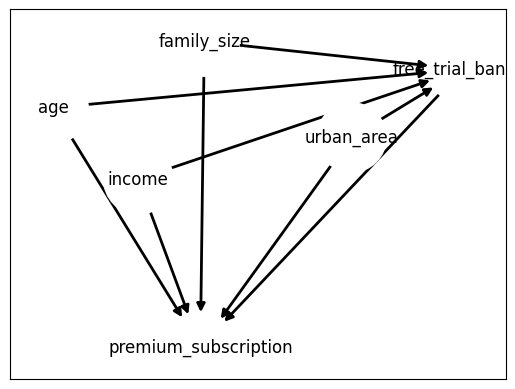

In [53]:
edges = [
    ('free_trial_banner', 'premium_subscription'),
    ('income', 'premium_subscription'),
    ('age', 'premium_subscription'),
    ('urban_area', 'premium_subscription'),
    ('family_size', 'premium_subscription'),
    ('income', 'free_trial_banner'),
    ('age', 'free_trial_banner'),
    ('urban_area', 'free_trial_banner'),
    ('family_size', 'free_trial_banner')
]
G = nx.DiGraph(directed = True)
G.add_edges_from(edges)
nx_options = {'node_color': 'white', 'node_size': 2500, 'width': 2,
              'arrowstyle': '-|>', 'arrowsize': 12}
np.random.seed(8)
nx.draw_networkx(G, arrows = True, **nx_options)
plt.show()

In [54]:
bn_cols = ['income_bin', 'age_bin', 'urban_area', 'family_size',
           'free_trial_banner', 'premium_subscription']

income_bins = pd.qcut(df_train['income'], q = 3, retbins = True, duplicates = 'drop')[1]
age_bins = pd.qcut(df_train['age'], q = 3, retbins = True, duplicates = 'drop')[1]
income_bins[0], income_bins[-1] = -np.inf, np.inf
age_bins[0], age_bins[-1] = -np.inf, np.inf

df_bn_train = df_train.copy()
df_bn_test = df_test.copy()
for data in [df_bn_train, df_bn_test]:
    data['income_bin'] = pd.cut(data['income'], bins = income_bins, labels = False, include_lowest = True).astype(int)
    data['age_bin'] = pd.cut(data['age'], bins = age_bins, labels = False, include_lowest = True).astype(int)

df_bn_train = df_bn_train[bn_cols].astype(int).reset_index(drop = True)
df_bn_test = df_bn_test[bn_cols].astype(int).reset_index(drop = True)

In [55]:
edges_bn = [
    ('free_trial_banner', 'premium_subscription'),
    ('income_bin', 'premium_subscription'),
    ('age_bin', 'premium_subscription'),
    ('urban_area', 'premium_subscription'),
    ('family_size', 'premium_subscription'),
    ('income_bin', 'free_trial_banner'),
    ('age_bin', 'free_trial_banner'),
    ('urban_area', 'free_trial_banner'),
    ('family_size', 'free_trial_banner')
]
DAG_user = bnlearn.make_DAG(edges_bn)
bn_user = bnlearn.parameter_learning.fit(DAG_user, df_bn_train, methodtype = 'ml')

[bnlearn]> Auto generate placeholders for the CPTs.
[bnlearn] >CPT for premium_subscription:
+-------------------------+-----+----------------------+
| free_trial_banner       | ... | free_trial_banner(1) |
+-------------------------+-----+----------------------+
| income_bin              | ... | income_bin(1)        |
+-------------------------+-----+----------------------+
| age_bin                 | ... | age_bin(1)           |
+-------------------------+-----+----------------------+
| urban_area              | ... | urban_area(1)        |
+-------------------------+-----+----------------------+
| family_size             | ... | family_size(1)       |
+-------------------------+-----+----------------------+
| premium_subscription(0) | ... | 0.5                  |
+-------------------------+-----+----------------------+
| premium_subscription(1) | ... | 0.5                  |
+-------------------------+-----+----------------------+
[bnlearn] >CPT for free_trial_banner:
+-------------

In [56]:
features_bn_test = df_bn_test.drop(columns = ['premium_subscription'])
target_bn_test = df_bn_test['premium_subscription']

predict_bn_user = bnlearn.predict(bn_user, df = features_bn_test, variables = ['premium_subscription'])
prediction_bn_user = predict_bn_user.loc[:, 'premium_subscription']
ACC_bn_user_test = np.mean(target_bn_test.values == prediction_bn_user.values)
print(ACC_bn_user_test)

[bnlearn]> Remaining columns for inference: 5


100%|██████████| 177/177 [00:00<00:00, 4023.08it/s]

0.6766666666666666


[bnlearn] >Computing best DAG using [hc]
[bnlearn] >Set scoring type at [bic]
[bnlearn] >Compute structure scores for model comparison (higher is better).
[bnlearn] >No changes made to existing bayes DAG.
[bnlearn] >Parameter learning> Computing parameters using [ml]
[bnlearn] >Converting [<class 'pgmpy.base.DAG.DAG'>] to BayesianNetwork model.
[bnlearn] >Converting adjmat to BayesianNetwork.
[bnlearn] >CPD of income_bin:
+---------------+----------+
| income_bin(0) | 0.333333 |
+---------------+----------+
| income_bin(1) | 0.333333 |
+---------------+----------+
| income_bin(2) | 0.333333 |
+---------------+----------+
[bnlearn] >CPD of free_trial_banner:
+----------------------+-----+-------------------------+
| age_bin              | ... | age_bin(2)              |
+----------------------+-----+-------------------------+
| income_bin           | ... | income_bin(2)           |
+----------------------+-----+-------------------------+
| premium_subscription | ... | premium_subscripti

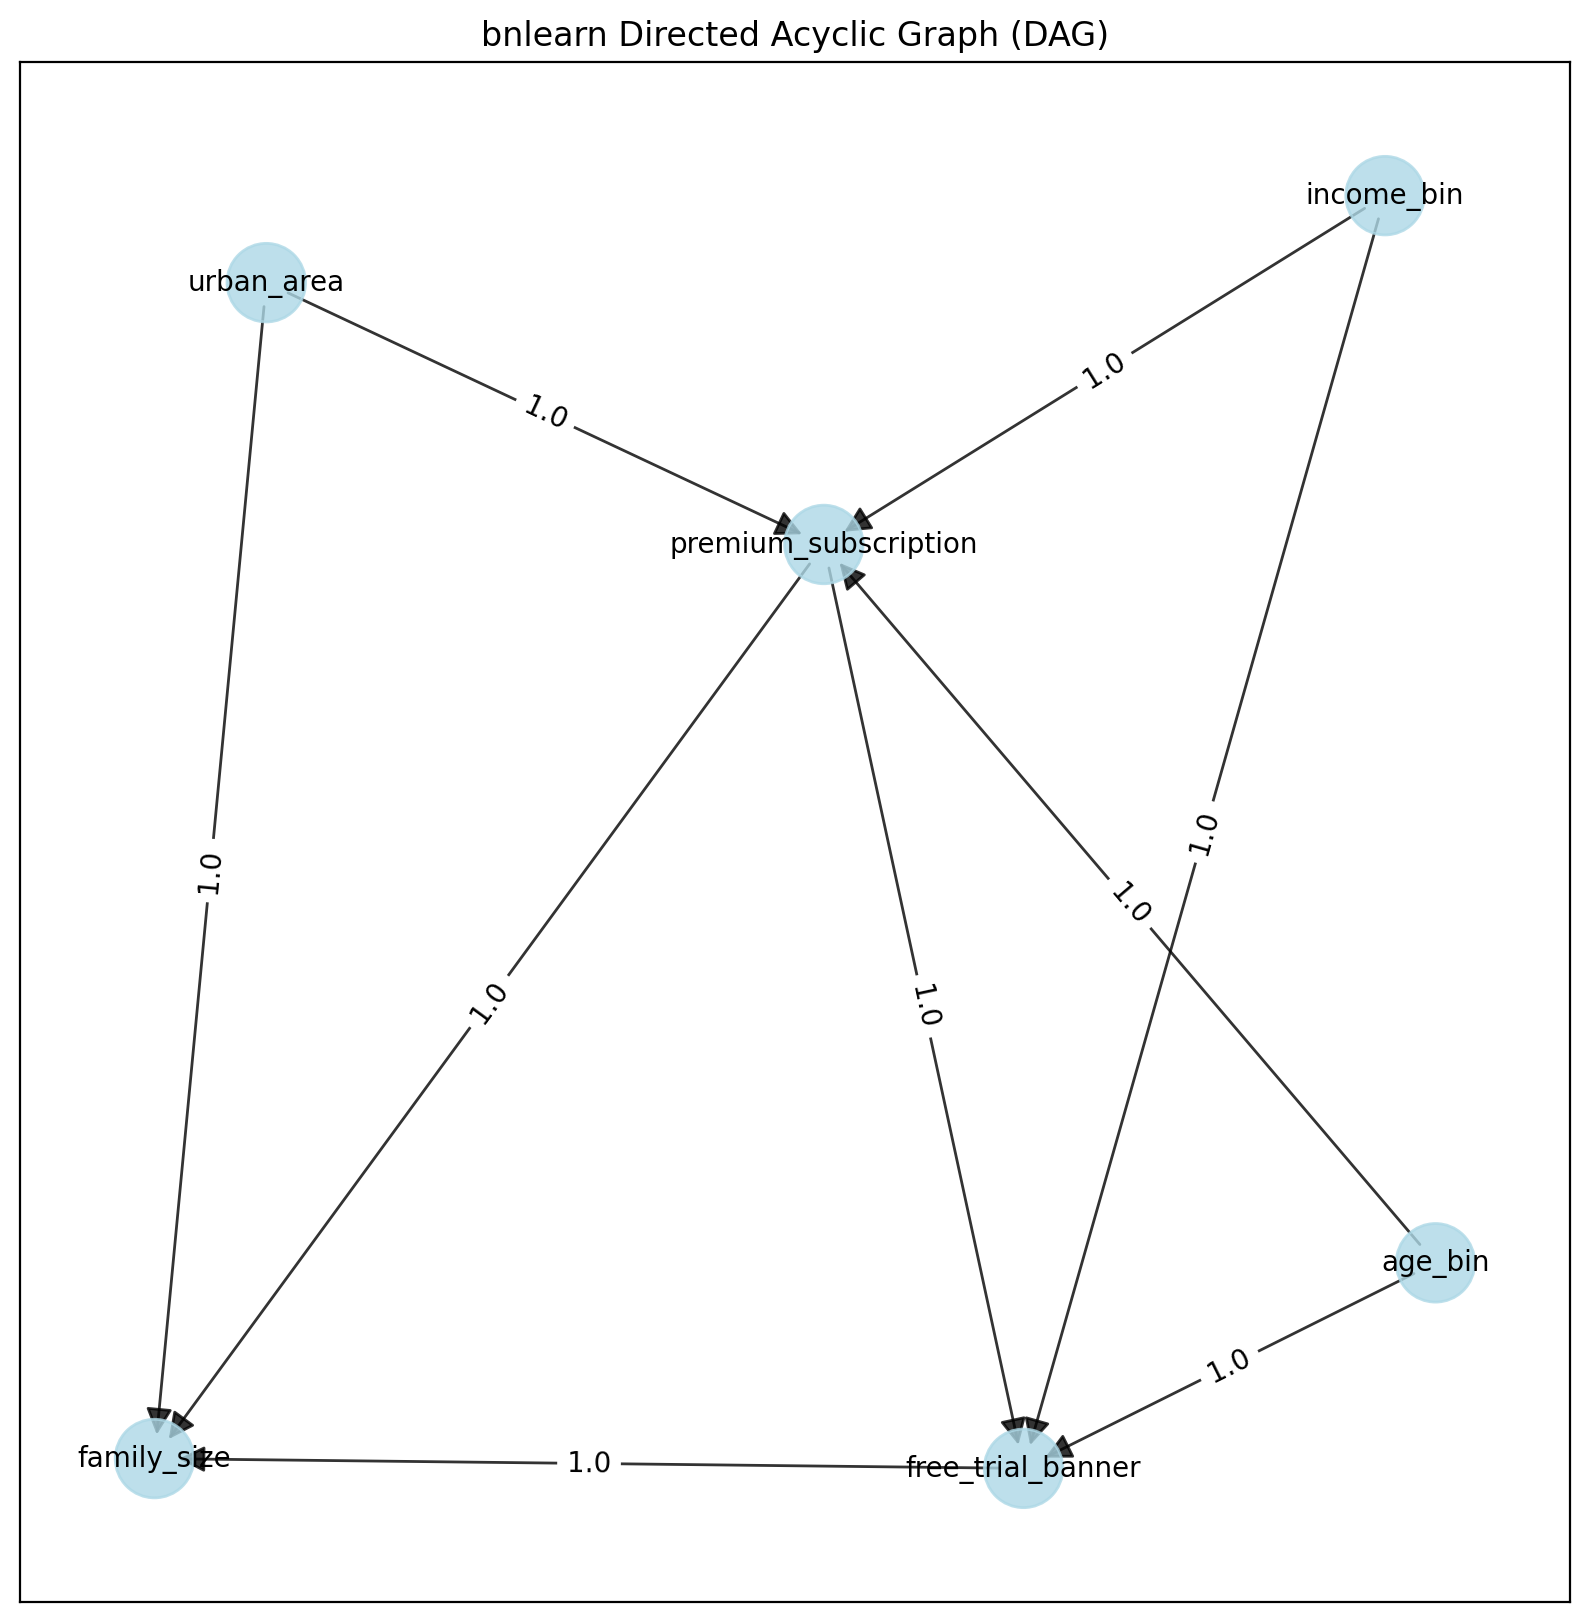

{'fig': <Figure size 2000x2000 with 1 Axes>,
 'ax': <Figure size 2000x2000 with 1 Axes>,
 'pos': {'income_bin': array([0.77409627, 0.45494942]),
  'free_trial_banner': array([ 0.25292315, -0.40527418]),
  'premium_subscription': array([-0.03499225,  0.21918287]),
  'age_bin': array([ 0.84681188, -0.26634153]),
  'urban_area': array([-0.83883905,  0.39613742]),
  'family_size': array([-1.        , -0.39865399])},
 'G': <networkx.classes.digraph.DiGraph at 0x15555b530>,
 'node_properties': {'income_bin': {'node_color': '#ADD8E6', 'node_size': 800},
  'age_bin': {'node_color': '#ADD8E6', 'node_size': 800},
  'urban_area': {'node_color': '#ADD8E6', 'node_size': 800},
  'family_size': {'node_color': '#ADD8E6', 'node_size': 800},
  'free_trial_banner': {'node_color': '#ADD8E6', 'node_size': 800},
  'premium_subscription': {'node_color': '#ADD8E6', 'node_size': 800}},
 'edge_properties': {('income_bin', 'free_trial_banner'): {'color': '#000000',
   'weight': np.float64(1.0),
   'pvalue': 1,
 

In [57]:
bn_struct = bnlearn.structure_learning.fit(df_bn_train, methodtype = 'hc')
DAG_learned = bnlearn.make_DAG(bn_struct)
bn_learned = bnlearn.parameter_learning.fit(DAG_learned, df_bn_train, methodtype = 'ml')
bnlearn.plot(bn_learned, interactive = False)

In [58]:
predict_bn_learned = bnlearn.predict(bn_learned, df = features_bn_test, variables = ['premium_subscription'])
prediction_bn_learned = predict_bn_learned.loc[:, 'premium_subscription']
ACC_bn_learned_test = np.mean(target_bn_test.values == prediction_bn_learned.values)

print(pd.DataFrame(data = [ACC_bn_user_test, ACC_bn_learned_test],
                   index = ['Пользовательский DAG', 'Обученный DAG'],
                   columns = ['ACC test']))

[bnlearn]> Remaining columns for inference: 5


100%|██████████| 177/177 [00:00<00:00, 3644.73it/s]

                      ACC test
Пользовательский DAG  0.676667
Обученный DAG         0.675733


In [59]:
def bn_positive_class_probability(prediction_table, target_col = 'premium_subscription'):
    predicted_class = prediction_table[target_col].astype(int).to_numpy()
    predicted_class_probability = prediction_table['p'].astype(float).to_numpy()
    positive_probability = np.where(predicted_class == 1,
                                    predicted_class_probability,
                                    1 - predicted_class_probability)
    return positive_probability

features_bn_train = df_bn_train.drop(columns = ['premium_subscription'])
target_bn_train = df_bn_train['premium_subscription']

predict_bn_user_train = bnlearn.predict(bn_user, df = features_bn_train, variables = ['premium_subscription'])
predict_bn_learned_train = bnlearn.predict(bn_learned, df = features_bn_train, variables = ['premium_subscription'])

bn_user_prob_train = bn_positive_class_probability(predict_bn_user_train)
bn_user_prob_test = bn_positive_class_probability(predict_bn_user)
bn_learned_prob_train = bn_positive_class_probability(predict_bn_learned_train)
bn_learned_prob_test = bn_positive_class_probability(predict_bn_learned)

[bnlearn]> Remaining columns for inference: 5


100%|██████████| 179/179 [00:00<00:00, 3573.99it/s]


[bnlearn]> Remaining columns for inference: 5


100%|██████████| 179/179 [00:00<00:00, 3354.89it/s]


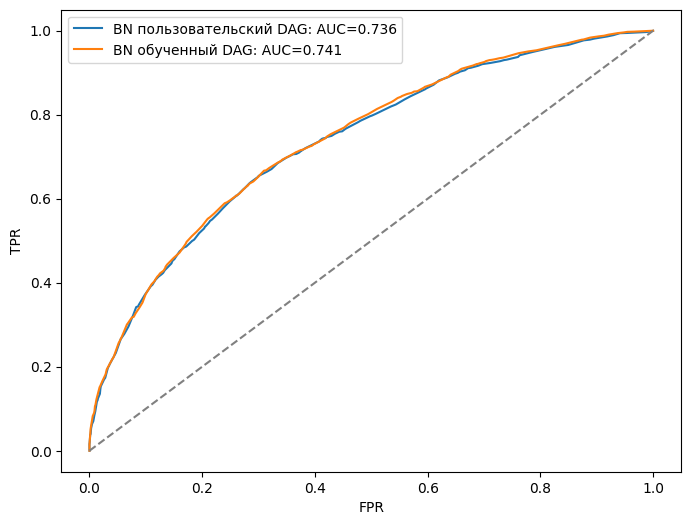

,AUC
Байесовская сеть: пользовательский DAG,0.736328
Байесовская сеть: обученный DAG,0.740514


In [60]:
bn_user_fpr, bn_user_tpr, _ = metrics.roc_curve(target_bn_test, bn_user_prob_test)
bn_learned_fpr, bn_learned_tpr, _ = metrics.roc_curve(target_bn_test, bn_learned_prob_test)

bn_user_auc = metrics.roc_auc_score(target_bn_test, bn_user_prob_test)
bn_learned_auc = metrics.roc_auc_score(target_bn_test, bn_learned_prob_test)

plt.figure(figsize = (8, 6))
plt.plot(bn_user_fpr, bn_user_tpr, label = f'BN пользовательский DAG: AUC={bn_user_auc:.3f}')
plt.plot(bn_learned_fpr, bn_learned_tpr, label = f'BN обученный DAG: AUC={bn_learned_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color = 'gray')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

bn_auc_table = pd.DataFrame({
    'AUC': [bn_user_auc, bn_learned_auc]
}, index = ['Байесовская сеть: пользовательский DAG',
            'Байесовская сеть: обученный DAG'])
bn_auc_table

In [61]:
auc_with_bn_table = pd.concat([
    classification_auc_table,
    bn_auc_table
]).sort_values('AUC', ascending = False)

best_base_auc_model = classification_auc_table['AUC'].idxmax()
best_base_auc = classification_auc_table.loc[best_base_auc_model, 'AUC']
best_bn_auc_model = bn_auc_table['AUC'].idxmax()
best_bn_auc = bn_auc_table.loc[best_bn_auc_model, 'AUC']

auc_with_bn_table

,AUC
Градиентный бустинг,0.763548
Случайный лес,0.760400
KNN,0.758051
Наивный Байес,0.741878
Байесовская сеть: обученный DAG,0.740514
Байесовская сеть: пользовательский DAG,0.736328
Логит,0.729304


In [62]:
print('Лучшая базовая модель по AUC:', best_base_auc_model, best_base_auc)
print('Лучшая Байесовская сеть по AUC:', best_bn_auc_model, best_bn_auc)
print('Разница AUC лучшей базовой модели и лучшей BN:', best_base_auc - best_bn_auc)

Лучшая базовая модель по AUC: Градиентный бустинг 0.7635481846418621
Лучшая Байесовская сеть по AUC: Байесовская сеть: обученный DAG 0.7405140003306955
Разница AUC лучшей базовой модели и лучшей BN: 0.02303418431116666


## 3.9 Лучший и худший классификатор

In [63]:
final = classification_all_summary.loc[:, ['test-ACC после тюнинга',
                                           'test-AUC после тюнинга',
                                           'CV-ACC после тюнинга']].rename(columns = {
    'test-ACC после тюнинга': 'test-ACC',
    'test-AUC после тюнинга': 'AUC',
    'CV-ACC после тюнинга': 'CV-ACC'
})
final.sort_values('AUC', ascending = False)

,test-ACC,AUC,CV-ACC
модель,,,
Градиентный бустинг,0.688133,0.763548,0.695956
Случайный лес,0.685333,0.760400,0.693911
KNN,0.684533,0.758051,0.693200
Наивный Байес,0.670133,0.741878,0.673911
Логит,0.665467,0.729304,0.669422


In [64]:
best_model = final['AUC'].idxmax()
worst_model = final['AUC'].idxmin()
top3_classifiers = final.sort_values('AUC', ascending = False).head(3)

print('Три лучших классификатора по AUC:')
print(top3_classifiers)
print()
print('Лучшая модель:', best_model)
print('Худшая модель:', worst_model)

Три лучших классификатора по AUC:
                     test-ACC       AUC    CV-ACC
модель                                           
Градиентный бустинг  0.688133  0.763548  0.695956
Случайный лес        0.685333  0.760400  0.693911
KNN                  0.684533  0.758051  0.693200

Лучшая модель: Градиентный бустинг
Худшая модель: Логит


## 3.10 CatBoost (дополнительный метод)

In [65]:
cat_feature_names = ['urban_area', 'family_size', 'free_trial_banner']
cat_features = [features_train_raw.columns.get_loc(col) for col in cat_feature_names]

catboost_model = CatBoostClassifier(loss_function = 'Logloss',
                                    eval_metric = 'AUC',
                                    random_seed = 777,
                                    verbose = False,
                                    allow_writing_files = False,
                                    thread_count = 1)

catboost_param_grid = {
    'iterations': [100, 300],
    'depth': [3, 4],
    'learning_rate': [0.03, 0.1],
    'l2_leaf_reg': [1, 3]
}

In [66]:
GSCV_catboost = GridSearchCV(estimator = catboost_model,
                             param_grid = catboost_param_grid,
                             scoring = 'accuracy',
                             cv = cv_all,
                             n_jobs = 1)
GSCV_catboost.fit(features_train_raw, target_train, cat_features = cat_features)

catboost_best = GSCV_catboost.best_estimator_
catboost_best_params = GSCV_catboost.best_params_
catboost_pred_train = catboost_best.predict(features_train_raw).astype(int)
catboost_pred_test = catboost_best.predict(features_test_raw).astype(int)
catboost_prob_test = catboost_best.predict_proba(features_test_raw)[:, 1]

catboost_linear_threshold, catboost_linear_profit = best_threshold_profit(catboost_best,
                                                                          features_train_raw, target_train,
                                                                          features_test_raw, target_test,
                                                                          prices)
catboost_nonlinear_threshold, catboost_nonlinear_train_profit, catboost_nonlinear_test_details = best_threshold_nonlinear_profit(
    catboost_best, features_train_raw, target_train, features_test_raw, target_test)

catboost_summary = pd.DataFrame({
    'лучшие гиперпараметры': [str(catboost_best_params)],
    'train-ACC': [accuracy_score(target_train, catboost_pred_train)],
    'CV-ACC': [GSCV_catboost.best_score_],
    'test-ACC': [accuracy_score(target_test, catboost_pred_test)],
    'test-F1': [f1_score(target_test, catboost_pred_test)],
    'test-AUC': [metrics.roc_auc_score(target_test, catboost_prob_test)],
    'test custom utility': [custom_weighted_utility(target_test, catboost_pred_test)],
    'linear profit threshold': [catboost_linear_threshold],
    'test linear profit': [catboost_linear_profit],
    'nonlinear profit threshold': [catboost_nonlinear_threshold],
    'test nonlinear profit': [catboost_nonlinear_test_details['nonlinear_profit']]
}, index = ['CatBoost'])
catboost_summary

,лучшие гиперпараметры,train-ACC,CV-ACC,test-ACC,test-F1,test-AUC,test custom utility,linear profit threshold,test linear profit,nonlinear profit threshold,test nonlinear profit
CatBoost,"{'depth': 4, 'iterations': 300, 'l2_leaf_reg':...",0.704133,0.697867,0.685733,0.670396,0.76284,0.3396,0.174266,21600,0.15,23087.928


In [67]:
best_course_model_name = best_model
best_course_model = all_classification_models[best_course_model_name]
best_course_pred_test = best_course_model.predict(features_test_raw)
best_course_prob_test = best_course_model.predict_proba(features_test_raw)[:, 1]

catboost_comparison = pd.DataFrame({
    'test-ACC': [final.loc[best_course_model_name, 'test-ACC'],
                 catboost_summary.loc['CatBoost', 'test-ACC']],
    'test-F1': [classification_all_summary.loc[best_course_model_name, 'test-F1 после тюнинга'],
                catboost_summary.loc['CatBoost', 'test-F1']],
    'test-AUC': [final.loc[best_course_model_name, 'AUC'],
                 catboost_summary.loc['CatBoost', 'test-AUC']],
    'test custom utility': [custom_weighted_utility(target_test, best_course_pred_test),
                            catboost_summary.loc['CatBoost', 'test custom utility']],
    'test linear profit': [profit_table.loc[best_course_model_name, 'прибыль на тесте'],
                           catboost_summary.loc['CatBoost', 'test linear profit']],
    'test nonlinear profit': [nonlinear_profit_table.loc[best_course_model_name, 'test nonlinear profit'],
                              catboost_summary.loc['CatBoost', 'test nonlinear profit']]
}, index = [best_course_model_name, 'CatBoost'])
catboost_comparison

,test-ACC,test-F1,test-AUC,test custom utility,test linear profit,test nonlinear profit
Градиентный бустинг,0.688133,0.675274,0.763548,0.3584,17700,19959.288
CatBoost,0.685733,0.670396,0.762840,0.3396,21600,23087.928


In [68]:
catboost_auc_row = pd.DataFrame({'AUC': [catboost_summary.loc['CatBoost', 'test-AUC']]},
                                index = ['CatBoost'])
auc_with_catboost_table = pd.concat([classification_auc_table, catboost_auc_row]).sort_values('AUC', ascending = False)
auc_with_catboost_table

,AUC
Градиентный бустинг,0.763548
CatBoost,0.762840
Случайный лес,0.760400
KNN,0.758051
Наивный Байес,0.741878
Логит,0.729304


In [69]:
best_model_with_catboost = auc_with_catboost_table['AUC'].idxmax()
catboost_auc_gap = catboost_summary.loc['CatBoost', 'test-AUC'] - final.loc[best_course_model_name, 'AUC']

print('Лучшая модель из методов курса:', best_course_model_name)
print('Лучшая модель после добавления CatBoost:', best_model_with_catboost)
print('Разница AUC CatBoost и лучшей модели курса:', catboost_auc_gap)

Лучшая модель из методов курса: Градиентный бустинг
Лучшая модель после добавления CatBoost: Градиентный бустинг
Разница AUC CatBoost и лучшей модели курса: -0.0007080083420599736


## 4.1 Отбор признаков

In [70]:
df = pd.read_csv("data/df.csv")
df.head()

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner
0,11721.117830,1,38452.719412,24.0,1,2,0
1,10911.269377,1,108953.092363,27.0,1,2,1
2,8642.447791,0,76228.390348,53.0,1,1,0
3,1.000000,0,31158.820400,52.0,1,1,0
4,7228.550018,0,49548.133698,48.0,0,3,0


In [71]:
target = np.ravel(df.loc[:, ['monthly_spending']])
features = df.loc[:, ['income', 'age', 'urban_area', 'family_size', 'free_trial_banner']]

pd.DataFrame({
    'переменная': ['monthly_spending'] + list(features.columns),
    'роль': ['целевая переменная'] + ['признак'] * features.shape[1]
})

,переменная,роль
0,monthly_spending,целевая переменная
1,income,признак
2,age,признак
3,urban_area,признак
4,family_size,признак
5,free_trial_banner,признак


In [72]:
features_train, features_test, target_train, target_test = train_test_split(
    features, target, test_size = 0.25, random_state = 123)

features_train_raw = features_train.copy()
features_test_raw = features_test.copy()

pd.Series({
    'n_train': len(target_train),
    'n_test': len(target_test),
    'test_share': len(target_test) / len(target)
})

n_train       22500.00
n_test         7500.00
test_share        0.25
dtype: float64

## 4.2 RMSE/MAPE и тюнинг гиперпараметров

In [73]:
cv_all_reg = 5

def rmse(y_true, y_pred):
    return np.sqrt(metrics.mean_squared_error(y_true, y_pred))

def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan
    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]))

mape_scorer = make_scorer(mape, greater_is_better = False)

In [74]:
regression_initial_models = {
    'МНК': LinearRegression(),
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsRegressor(n_neighbors = 25, weights = 'distance'))
    ]),
    'Случайный лес': RandomForestRegressor(max_depth = 10,
                                           max_features = 'sqrt',
                                           n_estimators = 100,
                                           random_state = 777,
                                           criterion = 'squared_error'),
    'Градиентный бустинг': GradientBoostingRegressor(loss = 'squared_error',
                                                     n_estimators = 120,
                                                     learning_rate = 0.07,
                                                     max_depth = 3,
                                                     random_state = 123)
}

regression_initial_params = {
    'МНК': 'нет настраиваемых гиперпараметров',
    'KNN': 'n_neighbors=25, weights=distance, StandardScaler',
    'Случайный лес': 'max_depth=10, max_features=sqrt, n_estimators=100',
    'Градиентный бустинг': 'max_depth=3, learning_rate=0.07, n_estimators=120'
}

pd.Series(regression_initial_params, name = 'исходные гиперпараметры')

МНК                                    нет настраиваемых гиперпараметров
KNN                     n_neighbors=25, weights=distance, StandardScaler
Случайный лес          max_depth=10, max_features=sqrt, n_estimators=100
Градиентный бустинг    max_depth=3, learning_rate=0.07, n_estimators=120
Name: исходные гиперпараметры, dtype: object

In [75]:
initial_rows = []

for model_name, model in regression_initial_models.items():
    model.fit(features_train_raw, target_train)
    pred_train = model.predict(features_train_raw)
    pred_test = model.predict(features_test_raw)
    rmse_cv = -np.mean(cross_val_score(model, features_train_raw, target_train,
                                       cv = cv_all_reg,
                                       scoring = 'neg_root_mean_squared_error'))
    mape_cv = -np.mean(cross_val_score(model, features_train_raw, target_train,
                                       cv = cv_all_reg,
                                       scoring = mape_scorer))

    initial_rows.append({
        'модель': model_name,
        'RMSE train до тюнинга': rmse(target_train, pred_train),
        'MAPE train до тюнинга': mape(target_train, pred_train),
        'RMSE test до тюнинга': rmse(target_test, pred_test),
        'MAPE test до тюнинга': mape(target_test, pred_test),
        'RMSE-CV до тюнинга': rmse_cv,
        'MAPE-CV до тюнинга': mape_cv
    })

regression_initial_summary = pd.DataFrame(initial_rows).set_index('модель')
regression_initial_summary.round(3)

,RMSE train до тюнинга,MAPE train до тюнинга,RMSE test до тюнинга,MAPE test до тюнинга,RMSE-CV до тюнинга,MAPE-CV до тюнинга
модель,,,,,,
МНК,5005.002,99.786,4983.135,97.411,5005.652,99.750
KNN,0.000,0.000,5004.848,99.046,5034.773,97.389
Случайный лес,4372.273,89.032,4749.337,99.927,4769.502,99.504
Градиентный бустинг,4672.241,95.501,4708.211,96.569,4729.153,96.689


In [76]:
regression_param_grids = {
    'МНК': {},
    'KNN': {'model__n_neighbors': [15, 25, 45],
            'model__weights': ['uniform', 'distance']},
    'Случайный лес': {'max_depth': [8, 10, 14],
                      'max_features': ['sqrt', None],
                      'n_estimators': [80, 120]},
    'Градиентный бустинг': {'max_depth': [2, 3],
                            'learning_rate': [0.05, 0.1],
                            'n_estimators': [80, 120]}
}

pd.Series({model_name: str(grid) for model_name, grid in regression_param_grids.items()},
          name = 'сетка гиперпараметров')

МНК                                                                   {}
KNN                    {'model__n_neighbors': [15, 25, 45], 'model__w...
Случайный лес          {'max_depth': [8, 10, 14], 'max_features': ['s...
Градиентный бустинг    {'max_depth': [2, 3], 'learning_rate': [0.05, ...
Name: сетка гиперпараметров, dtype: object

In [77]:
all_regression_rows = []
all_regression_models = {}

for model_name, model in regression_initial_models.items():
    initial_metrics = regression_initial_summary.loc[model_name]

    if regression_param_grids[model_name]:
        grid = GridSearchCV(estimator = model,
                            param_grid = regression_param_grids[model_name],
                            scoring = 'neg_root_mean_squared_error',
                            cv = cv_all_reg,
                            n_jobs = -1)
        grid.fit(features_train_raw, target_train)
        tuned_model = grid.best_estimator_
        best_params = grid.best_params_
        rmse_cv_tuned = -grid.best_score_
    else:
        tuned_model = model
        tuned_model.fit(features_train_raw, target_train)
        best_params = {}
        rmse_cv_tuned = initial_metrics['RMSE-CV до тюнинга']

    all_regression_models[model_name] = tuned_model
    pred_train_tuned = tuned_model.predict(features_train_raw)
    pred_test_tuned = tuned_model.predict(features_test_raw)
    mape_cv_tuned = -np.mean(cross_val_score(tuned_model, features_train_raw, target_train,
                                             cv = cv_all_reg,
                                             scoring = mape_scorer))

    all_regression_rows.append({
        'модель': model_name,
        'исходные гиперпараметры': regression_initial_params[model_name],
        'подобранные гиперпараметры': str(best_params),
        'RMSE train до тюнинга': initial_metrics['RMSE train до тюнинга'],
        'RMSE train после тюнинга': rmse(target_train, pred_train_tuned),
        'MAPE train до тюнинга': initial_metrics['MAPE train до тюнинга'],
        'MAPE train после тюнинга': mape(target_train, pred_train_tuned),
        'RMSE test до тюнинга': initial_metrics['RMSE test до тюнинга'],
        'RMSE test после тюнинга': rmse(target_test, pred_test_tuned),
        'MAPE test до тюнинга': initial_metrics['MAPE test до тюнинга'],
        'MAPE test после тюнинга': mape(target_test, pred_test_tuned),
        'RMSE-CV до тюнинга': initial_metrics['RMSE-CV до тюнинга'],
        'RMSE-CV после тюнинга': rmse_cv_tuned,
        'MAPE-CV до тюнинга': initial_metrics['MAPE-CV до тюнинга'],
        'MAPE-CV после тюнинга': mape_cv_tuned
    })

regression_all_summary = pd.DataFrame(all_regression_rows).set_index('модель')
regression_all_summary.sort_values('RMSE test после тюнинга').round(3)

,исходные гиперпараметры,подобранные гиперпараметры,RMSE train до тюнинга,RMSE train после тюнинга,MAPE train до тюнинга,MAPE train после тюнинга,RMSE test до тюнинга,RMSE test после тюнинга,MAPE test до тюнинга,MAPE test после тюнинга,RMSE-CV до тюнинга,RMSE-CV после тюнинга,MAPE-CV до тюнинга,MAPE-CV после тюнинга
модель,,,,,,,,,,,,,,
Градиентный бустинг,"max_depth=3, learning_rate=0.07, n_estimators=120","{'learning_rate': 0.1, 'max_depth': 3, 'n_esti...",4672.241,4659.323,95.501,93.603,4708.211,4710.356,96.569,94.661,4729.153,4728.383,96.689,95.459
Случайный лес,"max_depth=10, max_features=sqrt, n_estimators=100","{'max_depth': 8, 'max_features': 'sqrt', 'n_es...",4372.273,4605.232,89.032,100.148,4749.337,4732.914,99.927,104.132,4769.502,4760.947,99.504,104.097
KNN,"n_neighbors=25, weights=distance, StandardScaler","{'model__n_neighbors': 45, 'model__weights': '...",0.000,4660.883,0.000,99.555,5004.848,4760.314,99.046,103.207,5034.773,4771.433,97.389,102.986
МНК,нет настраиваемых гиперпараметров,{},5005.002,5005.002,99.786,99.786,4983.135,4983.135,97.411,97.411,5005.652,5005.652,99.750,99.750


In [78]:
overfitting_diagnostics = pd.DataFrame({
    'RMSE train после тюнинга': regression_all_summary['RMSE train после тюнинга'],
    'RMSE test после тюнинга': regression_all_summary['RMSE test после тюнинга'],
    'RMSE test-train gap': (regression_all_summary['RMSE test после тюнинга'] -
                            regression_all_summary['RMSE train после тюнинга']),
    'MAPE train после тюнинга': regression_all_summary['MAPE train после тюнинга'],
    'MAPE test после тюнинга': regression_all_summary['MAPE test после тюнинга'],
    'MAPE test-train gap': (regression_all_summary['MAPE test после тюнинга'] -
                            regression_all_summary['MAPE train после тюнинга'])
})

overfitting_diagnostics.sort_values('RMSE test-train gap', ascending = False).round(3)

,RMSE train после тюнинга,RMSE test после тюнинга,RMSE test-train gap,MAPE train после тюнинга,MAPE test после тюнинга,MAPE test-train gap
модель,,,,,,
Случайный лес,4605.232,4732.914,127.682,100.148,104.132,3.984
KNN,4660.883,4760.314,99.430,99.555,103.207,3.653
Градиентный бустинг,4659.323,4710.356,51.033,93.603,94.661,1.059
МНК,5005.002,4983.135,-21.867,99.786,97.411,-2.375


## 4.2* OOB для градиентного бустинга

In [79]:
pd.set_option('display.max_colwidth', 160)

gb_oob_grid = {
    'n_estimators': [80, 120],
    'learning_rate': [0.05, 0.1],
    'max_depth': [2, 3],
    'subsample': [0.6, 0.8]
}

def format_gb_params(params):
    return (f"n_estimators={params['n_estimators']}, "
            f"learning_rate={params['learning_rate']}, "
            f"max_depth={params['max_depth']}, "
            f"subsample={params['subsample']}")

gb_oob_param_list = [
    dict(zip(gb_oob_grid.keys(), values))
    for values in product(*gb_oob_grid.values())
]

pd.Series({key: values for key, values in gb_oob_grid.items()}, name = 'значения')

n_estimators       [80, 120]
learning_rate    [0.05, 0.1]
max_depth             [2, 3]
subsample         [0.6, 0.8]
Name: значения, dtype: object

In [80]:
gb_oob_rows = []
gb_oob_models = {}

for params in gb_oob_param_list:
    model = GradientBoostingRegressor(loss = 'squared_error',
                                      random_state = 123,
                                      **params)
    model.fit(features_train_raw, target_train)
    oob_error = model.oob_score_
    params_key = str(params)
    gb_oob_models[params_key] = model
    gb_oob_rows.append({
        'best_params': format_gb_params(params),
        'OOB error': oob_error,
        'OOB RMSE': np.sqrt(oob_error),
        'params_dict': params
    })

gb_oob_results = pd.DataFrame(gb_oob_rows).sort_values('OOB error').reset_index(drop = True)
gb_oob_best_params = gb_oob_results.loc[0, 'params_dict']
gb_oob_best_params_text = gb_oob_results.loc[0, 'best_params']
gb_oob_best_error = gb_oob_results.loc[0, 'OOB error']
gb_oob_best_model = gb_oob_models[str(gb_oob_best_params)]

gb_oob_results.drop(columns = 'params_dict').head(8)

,best_params,OOB error,OOB RMSE
0,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.6",2.141805e+07,4627.964061
1,"n_estimators=80, learning_rate=0.1, max_depth=3, subsample=0.8",2.153632e+07,4640.724102
2,"n_estimators=80, learning_rate=0.1, max_depth=3, subsample=0.6",2.173606e+07,4662.194413
3,"n_estimators=120, learning_rate=0.05, max_depth=3, subsample=0.6",2.178402e+07,4667.335854
4,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.8",2.185684e+07,4675.130395
5,"n_estimators=120, learning_rate=0.1, max_depth=2, subsample=0.6",2.185924e+07,4675.386666
6,"n_estimators=80, learning_rate=0.1, max_depth=2, subsample=0.8",2.212778e+07,4704.017135
7,"n_estimators=80, learning_rate=0.1, max_depth=2, subsample=0.6",2.222762e+07,4714.617374


In [81]:
gb_cv_grid = GridSearchCV(
    estimator = GradientBoostingRegressor(loss = 'squared_error', random_state = 123),
    param_grid = gb_oob_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = cv_all_reg,
    n_jobs = -1
)
gb_cv_grid.fit(features_train_raw, target_train)

gb_cv_best_params = gb_cv_grid.best_params_
gb_cv_best_params_text = format_gb_params(gb_cv_best_params)
gb_cv_best_rmse = -gb_cv_grid.best_score_
gb_cv_best_model = gb_cv_grid.best_estimator_

pd.DataFrame({
    'tuning_type': ['OOB', 'CV'],
    'best_params': [gb_oob_best_params_text, gb_cv_best_params_text],
    'OOB error': [gb_oob_best_error, np.nan],
    'CV RMSE': [np.nan, gb_cv_best_rmse]
})

,tuning_type,best_params,OOB error,CV RMSE
0,OOB,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.6",2.141805e+07,NaN
1,CV,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.8",NaN,4725.10134


In [82]:
best_regressor_name = regression_all_summary.sort_values('RMSE test после тюнинга').index[0]
best_regressor_all = all_regression_models[best_regressor_name]

gb_oob_pred_test = gb_oob_best_model.predict(features_test_raw)
gb_cv_pred_test = gb_cv_best_model.predict(features_test_raw)
main_best_pred_test = best_regressor_all.predict(features_test_raw)

comparison_oob_cv = pd.DataFrame({
    'method': ['GradientBoostingRegressor', 'GradientBoostingRegressor', best_regressor_name],
    'tuning_type': ['OOB', 'CV on same grid', 'main regression block'],
    'best_params': [gb_oob_best_params_text, gb_cv_best_params_text,
                    regression_all_summary.loc[best_regressor_name, 'подобранные гиперпараметры']],
    'OOB error': [gb_oob_best_error, np.nan, np.nan],
    'CV score': [np.nan, gb_cv_best_rmse,
                 regression_all_summary.loc[best_regressor_name, 'RMSE-CV после тюнинга']],
    'test RMSE': [rmse(target_test, gb_oob_pred_test),
                  rmse(target_test, gb_cv_pred_test),
                  rmse(target_test, main_best_pred_test)],
    'test MAPE': [mape(target_test, gb_oob_pred_test),
                  mape(target_test, gb_cv_pred_test),
                  mape(target_test, main_best_pred_test)]
})

comparison_oob_cv.round(3)

,method,tuning_type,best_params,OOB error,CV score,test RMSE,test MAPE
0,GradientBoostingRegressor,OOB,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.6",2.141805e+07,NaN,4710.766,94.355
1,GradientBoostingRegressor,CV on same grid,"n_estimators=120, learning_rate=0.1, max_depth=3, subsample=0.8",NaN,4725.101,4709.166,94.647
2,Градиентный бустинг,main regression block,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 120}",NaN,4728.383,4710.356,94.661


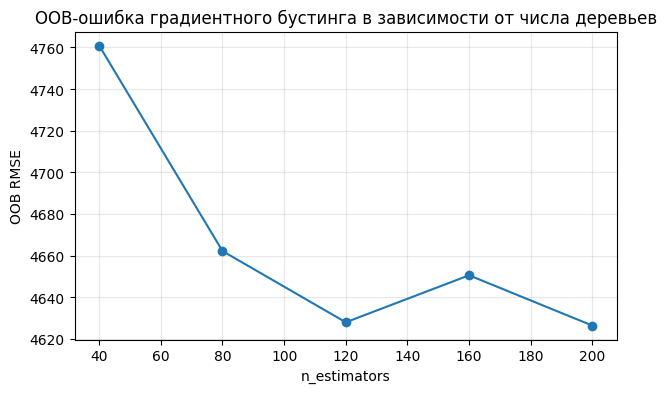

,n_estimators,OOB RMSE
0,40,4760.892748
1,80,4662.194413
2,120,4627.964061
3,160,4650.537397
4,200,4626.380678


In [83]:
oob_curve_rows = []
for n_estimators in [40, 80, 120, 160, 200]:
    curve_params = gb_oob_best_params.copy()
    curve_params['n_estimators'] = n_estimators
    model = GradientBoostingRegressor(loss = 'squared_error',
                                      random_state = 123,
                                      **curve_params)
    model.fit(features_train_raw, target_train)
    oob_curve_rows.append({
        'n_estimators': n_estimators,
        'OOB RMSE': np.sqrt(model.oob_score_)
    })

oob_curve = pd.DataFrame(oob_curve_rows)

plt.figure(figsize = (7, 4))
plt.plot(oob_curve['n_estimators'], oob_curve['OOB RMSE'], marker = 'o')
plt.xlabel('n_estimators')
plt.ylabel('OOB RMSE')
plt.title('OOB-ошибка градиентного бустинга в зависимости от числа деревьев')
plt.grid(alpha = 0.3)
plt.show()

oob_curve

## 4.3 Лучшая и худшая регрессия

In [84]:
regression_final_all = regression_all_summary[['RMSE test после тюнинга', 'MAPE test после тюнинга']].copy()
regression_final_all = regression_final_all.rename(columns = {
    'RMSE test после тюнинга': 'RMSE test',
    'MAPE test после тюнинга': 'MAPE test'
}).sort_values('RMSE test')

regression_final_all['RMSE gap vs best'] = regression_final_all['RMSE test'] - regression_final_all['RMSE test'].min()
regression_final_all['MAPE gap vs best'] = regression_final_all['MAPE test'] - regression_final_all['MAPE test'].min()

top3_regressors = regression_final_all.head(3)
best_regressor_name = regression_final_all.index[0]
worst_regressor_name = regression_final_all.index[-1]
best_regressor_all = all_regression_models[best_regressor_name]
worst_regressor_all = all_regression_models[worst_regressor_name]

print('Лучшая модель:', best_regressor_name)
print('Худшая модель:', worst_regressor_name)
print('Три лучшие модели по RMSE:')
print(top3_regressors[['RMSE test', 'MAPE test']])

regression_final_all.round(3)

Лучшая модель: Градиентный бустинг
Худшая модель: МНК
Три лучшие модели по RMSE:
                       RMSE test   MAPE test
модель                                      
Градиентный бустинг  4710.356026   94.661422
Случайный лес        4732.914491  104.132420
KNN                  4760.313711  103.207204


,RMSE test,MAPE test,RMSE gap vs best,MAPE gap vs best
модель,,,,
Градиентный бустинг,4710.356,94.661,0.000,0.000
Случайный лес,4732.914,104.132,22.558,9.471
KNN,4760.314,103.207,49.958,8.546
МНК,4983.135,97.411,272.779,2.750


## 4.4 CatBoost (дополнительный метод)

In [85]:
cat_features_train, cat_features_valid, cat_target_train, cat_target_valid = train_test_split(
    features_train_raw, target_train, test_size = 0.2, random_state = 321
)

catboost_param_grid = {
    'iterations': [120, 200],
    'depth': [3, 4],
    'learning_rate': [0.05, 0.1],
    'l2_leaf_reg': [3, 10]
}

catboost_param_list = [
    dict(zip(catboost_param_grid.keys(), values))
    for values in product(*catboost_param_grid.values())
]

pd.Series(catboost_param_grid, name = 'значения')

iterations        [120, 200]
depth                 [3, 4]
learning_rate    [0.05, 0.1]
l2_leaf_reg          [3, 10]
Name: значения, dtype: object

In [86]:
catboost_rows = []
catboost_models = {}

for params in catboost_param_list:
    model = CatBoostRegressor(loss_function = 'RMSE',
                              random_seed = 123,
                              verbose = False,
                              allow_writing_files = False,
                              **params)
    model.fit(cat_features_train, cat_target_train)
    valid_pred = model.predict(cat_features_valid)
    params_text = (f"iterations={params['iterations']}, depth={params['depth']}, "
                   f"learning_rate={params['learning_rate']}, l2_leaf_reg={params['l2_leaf_reg']}")
    catboost_models[params_text] = model
    catboost_rows.append({
        'best_params': params_text,
        'validation RMSE': rmse(cat_target_valid, valid_pred),
        'validation MAPE': mape(cat_target_valid, valid_pred),
        'params_dict': params
    })

catboost_tuning_results = pd.DataFrame(catboost_rows).sort_values('validation RMSE').reset_index(drop = True)
catboost_best_params = catboost_tuning_results.loc[0, 'params_dict']
catboost_best_params_text = catboost_tuning_results.loc[0, 'best_params']
catboost_best_validation_rmse = catboost_tuning_results.loc[0, 'validation RMSE']
catboost_best_validation_mape = catboost_tuning_results.loc[0, 'validation MAPE']

catboost_tuning_results.drop(columns = 'params_dict').head(8).round(3)

,best_params,validation RMSE,validation MAPE
0,"iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=3",4701.592,87.809
1,"iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=10",4703.712,87.663
2,"iterations=200, depth=4, learning_rate=0.1, l2_leaf_reg=3",4703.936,88.543
3,"iterations=200, depth=4, learning_rate=0.1, l2_leaf_reg=10",4704.318,88.170
4,"iterations=200, depth=4, learning_rate=0.05, l2_leaf_reg=3",4707.943,88.848
5,"iterations=120, depth=4, learning_rate=0.1, l2_leaf_reg=10",4708.272,88.294
6,"iterations=120, depth=4, learning_rate=0.1, l2_leaf_reg=3",4708.760,88.430
7,"iterations=200, depth=4, learning_rate=0.05, l2_leaf_reg=10",4708.920,88.958


In [87]:
catboost_best_model = CatBoostRegressor(loss_function = 'RMSE',
                                           random_seed = 123,
                                           verbose = False,
                                           allow_writing_files = False,
                                           **catboost_best_params)
catboost_best_model.fit(features_train_raw, target_train)
catboost_pred_test = catboost_best_model.predict(features_test_raw)

catboost_test_rmse = rmse(target_test, catboost_pred_test)
catboost_test_mape = mape(target_test, catboost_pred_test)

pd.Series({
    'best_params': catboost_best_params_text,
    'validation RMSE': catboost_best_validation_rmse,
    'validation MAPE': catboost_best_validation_mape,
    'test RMSE': catboost_test_rmse,
    'test MAPE': catboost_test_mape
})

best_params        iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=3
validation RMSE                                                  4701.591705
validation MAPE                                                    87.808643
test RMSE                                                        4698.182096
test MAPE                                                          94.002601
dtype: object

In [88]:
catboost_vs_main = pd.DataFrame({
    'method': [best_regressor_name, 'CatBoostRegressor'],
    'source': ['основной блок регрессии', 'дополнительный внешний метод'],
    'best_params': [regression_all_summary.loc[best_regressor_name, 'подобранные гиперпараметры'],
                    catboost_best_params_text],
    'validation/CV RMSE': [regression_all_summary.loc[best_regressor_name, 'RMSE-CV после тюнинга'],
                           catboost_best_validation_rmse],
    'test RMSE': [regression_final_all.loc[best_regressor_name, 'RMSE test'],
                  catboost_test_rmse],
    'test MAPE': [regression_final_all.loc[best_regressor_name, 'MAPE test'],
                  catboost_test_mape]
})

catboost_vs_main['RMSE gap vs main best'] = catboost_vs_main['test RMSE'] - regression_final_all.loc[best_regressor_name, 'RMSE test']
catboost_vs_main['MAPE gap vs main best'] = catboost_vs_main['test MAPE'] - regression_final_all.loc[best_regressor_name, 'MAPE test']

catboost_vs_main.round(3)

,method,source,best_params,validation/CV RMSE,test RMSE,test MAPE,RMSE gap vs main best,MAPE gap vs main best
0,Градиентный бустинг,основной блок регрессии,"{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 120}",4728.383,4710.356,94.661,0.000,0.000
1,CatBoostRegressor,дополнительный внешний метод,"iterations=200, depth=3, learning_rate=0.1, l2_leaf_reg=3",4701.592,4698.182,94.003,-12.174,-0.659


## 5.1 ATE и LATE

In [89]:
df_observed = pd.read_csv('data/df.csv')
df_train = pd.read_csv('data/df_train.csv')
df_test = pd.read_csv('data/df_test.csv')
df_full = pd.read_csv('data/df_full.csv')

print(pd.DataFrame(data    = [df_observed.shape[0], df_full.shape[0], df_train.shape[0], df_test.shape[0], df_train.shape[0] + df_test.shape[0]],
                   index   = ['df', 'df_full', 'df_train', 'df_test', 'df_train + df_test'],
                   columns = ['число наблюдений']))
print(df_observed.columns.tolist())

                    число наблюдений
df                             30000
df_full                        30000
df_train                       22500
df_test                         7500
df_train + df_test             30000
['monthly_spending', 'premium_subscription', 'income', 'age', 'urban_area', 'family_size', 'free_trial_banner']


In [90]:
n = df_full.shape[0]

In [91]:
observed_cols = ['monthly_spending', 'premium_subscription', 'income', 'age',
                 'urban_area', 'family_size', 'free_trial_banner']

check = pd.Series({col: np.allclose(df_observed[col], df_full[col]) for col in observed_cols}, name = 'совпадает')
print(check)

df = df_full.copy()

monthly_spending        True
premium_subscription    True
income                  True
age                     True
urban_area              True
family_size             True
free_trial_banner       True
Name: совпадает, dtype: bool


In [92]:
df_effects_full = df.copy()

monthly_spending_full = np.array(df_effects_full['monthly_spending'])
premium_subscription_full = np.array(df_effects_full['premium_subscription'])
free_trial_banner_full = np.array(df_effects_full['free_trial_banner'])
monthly_spending0_full = np.array(df_effects_full['monthly_spending0'])
monthly_spending1_full = np.array(df_effects_full['monthly_spending1'])
g0_full = np.array(df_effects_full['g0'])
g1_full = np.array(df_effects_full['g1'])
compliers_full = np.array(df_effects_full['ind_type'] == 'Complier')

df = df_effects_full.sample(n = 10000, random_state = 777).reset_index(drop = True)

monthly_spending = np.array(df['monthly_spending'])
premium_subscription = np.array(df['premium_subscription'])
free_trial_banner = np.array(df['free_trial_banner'])
monthly_spending0 = np.array(df['monthly_spending0'])
monthly_spending1 = np.array(df['monthly_spending1'])
g0 = np.array(df['g0'])
g1 = np.array(df['g1'])
compliers = np.array(df['ind_type'] == 'Complier')

df.head(10).style.format(precision = 2)

,monthly_spending,premium_subscription,income,age,urban_area,family_size,free_trial_banner,income_z,age_center,online_preference_raw,online_preference,free_trial_banner_index,free_trial_banner_prob,premium_index,premium_segment,premium1_prob,premium0_prob,premium1,premium0,ind_type,error0,error1,base_spending,g0_obs,g0_unobs,g0,treatment_effect_structural,g1_obs,g1_unobs,g1,monthly_spending0,monthly_spending1,TE,CATE
0,6871.32,0,162012.34,44.00,1,1,1,1.79,0.90,-1.79,0.14,0.75,0.77,-0.99,0.00,0.49,0.27,0,0,Never taker,508.27,1542.19,8868.97,8868.97,-2505.92,6363.05,6261.78,15130.75,-5547.53,9583.21,6871.32,11125.40,4254.08,3220.16
1,807.83,0,48708.57,54.00,1,2,0,-0.61,1.90,-1.24,0.23,-1.21,0.11,-3.25,0.00,0.08,0.04,0,0,Never taker,-1278.74,4733.51,3873.23,3873.23,-1786.65,2086.58,5007.51,8880.74,-3985.78,4894.96,807.83,9628.46,8820.63,2808.38
2,21833.26,1,330566.83,49.00,1,4,1,3.22,1.40,-1.09,0.25,0.75,0.77,0.67,1.00,0.87,0.66,1,0,Complier,-1091.54,-1574.60,16226.59,16226.59,-1584.24,14642.35,10721.79,26948.38,-3540.53,23407.85,13550.82,21833.26,8282.44,8765.50
3,5229.59,0,83036.41,18.00,1,2,0,0.45,-1.70,-0.47,0.38,0.44,0.67,-1.46,0.00,0.33,0.19,0,0,Never taker,-109.83,631.82,6044.08,6044.08,-704.66,5339.42,5527.46,11571.54,-1583.34,9988.20,5229.59,10620.02,5390.43,4648.78
4,2667.66,0,27458.50,44.00,0,2,0,-1.76,0.90,-2.36,0.09,-1.94,0.03,-3.45,0.00,0.06,0.03,0,0,Never taker,3479.18,2171.81,2374.28,2374.28,-3185.79,-811.52,3960.47,6334.75,-6992.01,-657.26,2667.66,1514.55,-1153.11,154.26
5,12512.81,0,117613.27,18.00,1,4,1,1.15,-1.70,0.58,0.64,0.38,0.65,1.66,1.00,0.95,0.84,0,0,Never taker,1163.58,6994.07,10489.13,10489.13,860.10,11349.23,9133.81,19622.94,1931.32,21554.26,12512.81,28548.33,16035.51,10205.03
6,11247.09,1,25809.83,35.00,0,4,0,-1.88,0.00,0.60,0.64,-2.24,0.01,-1.19,0.00,0.39,0.23,1,1,Always taker,-3066.09,-435.30,3746.28,3746.28,884.08,4630.36,5951.16,9697.44,1984.95,11682.39,1564.27,11247.09,9682.82,7052.03
7,7990.00,0,60320.84,48.00,1,5,0,-0.19,1.30,-0.38,0.41,-1.51,0.07,-0.17,1.00,0.71,0.46,1,0,Complier,-288.33,149.31,8845.38,8845.38,-567.05,8278.33,8234.37,17079.75,-1274.75,15805.00,7990.00,15954.31,7964.31,7526.67
8,14253.31,1,67487.11,26.00,1,1,1,0.04,-0.90,1.32,0.79,0.21,0.58,0.60,0.00,0.79,0.65,1,1,Always taker,370.53,-186.44,4877.57,4877.57,1895.64,6773.21,5337.63,10215.20,4224.55,14439.75,7143.74,14253.31,7109.57,7666.54
9,5479.22,0,39995.90,51.00,0,4,0,-1.01,1.60,-0.52,0.37,-2.16,0.02,-3.12,0.00,0.09,0.04,0,0,Never taker,2135.91,-2602.15,4124.53,4124.53,-781.22,3343.31,5760.22,9884.75,-1754.83,8129.93,5479.22,5527.78,48.56,4786.62


## 5.2 Oracle-оценки эффектов воздействия

In [93]:
TE_full = monthly_spending1_full - monthly_spending0_full
TE = monthly_spending1 - monthly_spending0
print(TE_full[0:10])

[ 5537.33307746  2487.70860932  -206.34559745  1986.29875689
  3495.98936191   629.63053737  8548.97004765  9523.01729882
 10149.03869903  9038.23390467]


In [94]:
ATE = np.mean(TE_full)
LATE = np.mean(TE_full[compliers_full])
ATET = np.mean(TE_full[premium_subscription_full == 1])

print(pd.DataFrame(data    = [ATE, LATE, ATET],
                   index   = ['ATE', 'LATE', 'ATET'],
                   columns = ['Оценка']))

           Оценка
ATE   6292.960475
LATE  6280.319157
ATET  7274.638232


[7783.71913682 6017.36120987 5772.2814999   939.14593385 6502.53104396
 5183.59795207 8234.62453899 5998.69725844 6951.41474348 8082.28595026]


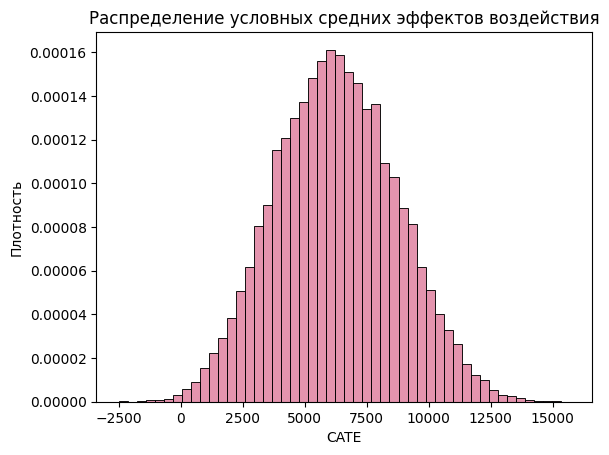

In [95]:
CATE_full = g1_full - g0_full
CATE = g1 - g0
print(CATE_full[0:10])

seaborn.histplot(CATE_full,
                 stat  = 'density',
                 color = 'palevioletred',
                 bins  = 50)
plt.xlabel('CATE')
plt.ylabel('Плотность')
plt.title('Распределение условных средних эффектов воздействия')
plt.show()

## 5.3 Наивная разница средних

In [96]:
ATE_naive = np.mean(monthly_spending[premium_subscription == 1]) - np.mean(monthly_spending[premium_subscription == 0])

print(pd.DataFrame(data    = [ATE, ATE_naive],
                   index   = ['ATE', 'ATE naive'],
                   columns = ['Оценка']))

                Оценка
ATE        6292.960475
ATE naive  9883.189426


## 5.4 Оценка ATE разными методами

In [97]:
controls = ['income', 'age', 'urban_area', 'family_size']
features = df.loc[:, controls]
target   = df.loc[:, ['premium_subscription']]
y        = df.loc[:, ['monthly_spending']]

best_classification = GradientBoostingClassifier(loss = 'log_loss',
                                                 n_estimators = 100,
                                                 learning_rate = 0.1,
                                                 max_depth = 2,
                                                 random_state = 123)
best_classification.fit(features, np.ravel(target))

best_regression = GradientBoostingRegressor(loss = 'squared_error',
                                            n_estimators = 120,
                                            learning_rate = 0.1,
                                            max_depth = 3,
                                            random_state = 123)
best_regression.fit(features, np.ravel(y))

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,120
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [98]:
y0  = df.loc[premium_subscription == 0, ['monthly_spending']]
x0  = df.loc[premium_subscription == 0, controls]
x0  = sm.add_constant(x0)
ls0 = sm.OLS(y0, x0).fit()

y1  = df.loc[premium_subscription == 1, ['monthly_spending']]
x1  = df.loc[premium_subscription == 1, controls]
x1  = sm.add_constant(x1)
ls1 = sm.OLS(y1, x1).fit()

x = df.loc[:, controls]
x = sm.add_constant(x)
monthly_spending0_ls = ls0.predict(x)
monthly_spending1_ls = ls1.predict(x)

CATE_ls = np.array(monthly_spending1_ls - monthly_spending0_ls)
ATE_ls = np.mean(CATE_ls)

print(pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls],
                   index   = ['ATE', 'ATE naive', 'ATE ls'],
                   columns = ['Оценка']))

                Оценка
ATE        6292.960475
ATE naive  9883.189426
ATE ls     8034.566740


In [99]:
rf = clone(best_regression)

x0_rf = df.loc[premium_subscription == 0, controls]
x1_rf = df.loc[premium_subscription == 1, controls]
x_rf  = df.loc[:, controls]

rf.fit(x0_rf, np.ravel(y0))
monthly_spending0_rf = rf.predict(x_rf)

rf.fit(x1_rf, np.ravel(y1))
monthly_spending1_rf = rf.predict(x_rf)

CATE_T = monthly_spending1_rf - monthly_spending0_rf
ATE_T = np.mean(CATE_T)

print(pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls, ATE_T],
                   index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means'],
                   columns = ['Оценка']))

                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7841.204849


In [100]:
dml_standard_data = dml.DoubleMLData(data   = df,
                                     y_col  = 'monthly_spending',
                                     d_cols = 'premium_subscription',
                                     x_cols = controls)

g_Y = clone(best_regression)
g_T = clone(best_classification)

np.random.seed(123)
dml_standard = dml.DoubleMLIRM(obj_dml_data = dml_standard_data,
                               ml_g         = g_Y,
                               ml_m         = g_T,
                               n_rep        = 1,
                               n_folds      = 5)

dml_standard.fit()
ATE_dml_standard = dml_standard.coef[0]
print(dml_standard)

================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: monthly_spending
Treatment variable(s): ['premium_subscription']
Covariates: ['income', 'age', 'urban_area', 'family_size']
Instrument variable(s): None
No. Observations: 10000

------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: GradientBoostingRegressor(n_estimators=120, random_state=123)
Learner ml_m: GradientBoostingClassifier(max_depth=2, random_state=123)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[2236.91954694]]
Learner ml_g1 RMSE: [[4115.61462301]]
Classification:
Learner ml_m Log Loss: [[0.5880917]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
                             coef    std err           t  P>|t|        2.5 %  \
prem

In [101]:
gb = clone(best_classification)
gb.fit(features, np.ravel(target))
prob_gb = gb.predict_proba(features)[:, 1]

print(pd.DataFrame(data    = [np.min(prob_gb), np.max(prob_gb)],
                   index   = ['min prob', 'max prob'],
                   columns = ['Оценка']))

monthly_spending_pseudo = ((monthly_spending * premium_subscription) / prob_gb -
                           (monthly_spending * (1 - premium_subscription)) / (1 - prob_gb))
ATE_IPW = np.mean(monthly_spending_pseudo)


            Оценка
min prob  0.012280
max prob  0.949853


In [102]:
ATE_DR = np.mean((monthly_spending1_rf - monthly_spending0_rf) +
                 premium_subscription * (monthly_spending - monthly_spending1_rf) / prob_gb -
                 (1 - premium_subscription) * (monthly_spending - monthly_spending0_rf) / (1 - prob_gb))

print(pd.DataFrame(data    = [ATE, ATE_naive, ATE_ls, ATE_T,
                              ATE_dml_standard, ATE_IPW, ATE_DR],
                   index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means',
                              'ATE dml standard', 'ATE IPW', 'ATE DR'],
                   columns = ['Оценка']))


                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7841.204849
ATE dml standard       7810.003445
ATE IPW                7816.842115
ATE DR                 7820.110448


In [103]:
# Повышенная сложность: PSM с caliper
psm_model = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(C = 1.0, penalty = 'l2', solver = 'lbfgs',
                                 fit_intercept = True, max_iter = 1000, random_state = 123))
])

propensity_score = psm_model.fit(features, np.ravel(target)).predict_proba(features)[:, 1]

df_psm = df.loc[:, controls + ['monthly_spending', 'premium_subscription']].copy()
df_psm['propensity_score'] = propensity_score

treated_mask = df_psm['premium_subscription'] == 1
control_mask  = df_psm['premium_subscription'] == 0

ps_lower = max(df_psm.loc[treated_mask, 'propensity_score'].min(),
               df_psm.loc[control_mask,  'propensity_score'].min())
ps_upper = min(df_psm.loc[treated_mask, 'propensity_score'].max(),
               df_psm.loc[control_mask,  'propensity_score'].max())

df_psm_common = df_psm.loc[df_psm['propensity_score'].between(ps_lower, ps_upper)].reset_index(drop = True)
logit_ps = np.log(df_psm_common['propensity_score'].clip(1e-6, 1 - 1e-6) /
                  (1 - df_psm_common['propensity_score'].clip(1e-6, 1 - 1e-6)))
df_psm_common['logit_ps'] = logit_ps
caliper = 0.2 * np.std(df_psm_common['logit_ps'])

treated_psm = df_psm_common.loc[df_psm_common['premium_subscription'] == 1].reset_index(drop = True)
control_psm  = df_psm_common.loc[df_psm_common['premium_subscription'] == 0].reset_index(drop = True)

nn_control = NearestNeighbors(n_neighbors = 1)
nn_control.fit(control_psm[['logit_ps']])
dist_t, idx_c = nn_control.kneighbors(treated_psm[['logit_ps']])
valid_t = dist_t[:, 0] <= caliper

nn_treated = NearestNeighbors(n_neighbors = 1)
nn_treated.fit(treated_psm[['logit_ps']])
dist_c, idx_t = nn_treated.kneighbors(control_psm[['logit_ps']])
valid_c = dist_c[:, 0] <= caliper

tau_t = (treated_psm.loc[valid_t, 'monthly_spending'].to_numpy() -
         control_psm.iloc[idx_c[valid_t, 0]]['monthly_spending'].to_numpy())
tau_c = (treated_psm.iloc[idx_t[valid_c, 0]]['monthly_spending'].to_numpy() -
         control_psm.loc[valid_c, 'monthly_spending'].to_numpy())

ATE_PSM = np.mean(np.concatenate([tau_t, tau_c]))

ATE_table_best = pd.DataFrame(
    data    = [ATE, ATE_naive, ATE_ls, ATE_T, ATE_dml_standard, ATE_IPW, ATE_DR, ATE_PSM],
    index   = ['ATE', 'ATE naive', 'ATE ls', 'ATE conditional means',
               'ATE dml standard', 'ATE IPW', 'ATE DR', 'ATE PSM'],
    columns = ['Оценка'])
print(ATE_table_best)


                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7841.204849
ATE dml standard       7810.003445
ATE IPW                7816.842115
ATE DR                 7820.110448
ATE PSM                8019.055227


## 5.5 Оценка CATE

In [104]:
y = df.loc[:, ['monthly_spending']]
x = df.loc[:, controls + ['premium_subscription']]

rf2 = clone(best_regression)
rf2.fit(x, np.ravel(y))

x0 = deepcopy(x)
x0['premium_subscription'] = 0
monthly_spending0_rf2 = rf2.predict(x0)

x1 = deepcopy(x)
x1['premium_subscription'] = 1
monthly_spending1_rf2 = rf2.predict(x1)

CATE_S = monthly_spending1_rf2 - monthly_spending0_rf2
ATE_S = np.mean(CATE_S)

In [105]:
rf3 = clone(best_regression)
rf3.fit(features, monthly_spending_pseudo)
CATE_CT = rf3.predict(features)

In [106]:
rf4 = clone(best_regression)
rf5 = clone(best_regression)

D1 = monthly_spending[premium_subscription == 1] - monthly_spending0_rf[premium_subscription == 1]
D0 = monthly_spending1_rf[premium_subscription == 0] - monthly_spending[premium_subscription == 0]

rf4.fit(features[premium_subscription == 0], D0)
CATE_X0 = rf4.predict(features)

rf5.fit(features[premium_subscription == 1], D1)
CATE_X1 = rf5.predict(features)

CATE_X = prob_gb * CATE_X0 + (1 - prob_gb) * CATE_X1
ATE_X = np.mean(CATE_X)

In [107]:
mu_model = clone(best_regression)
mu_model.fit(features, monthly_spending)
mu_hat = mu_model.predict(features)

propensity_r = np.clip(prob_gb, 0.05, 0.95)
residual_y = monthly_spending - mu_hat
residual_t = premium_subscription - propensity_r

rlearner_mask = np.abs(residual_t) >= 0.05
pseudo_outcome_r = residual_y[rlearner_mask] / residual_t[rlearner_mask]
weights_r = residual_t[rlearner_mask] ** 2

tau_model = clone(best_regression)
tau_model.fit(features.loc[rlearner_mask, :], pseudo_outcome_r, sample_weight = weights_r)

CATE_R = tau_model.predict(features)
ATE_R = np.mean(CATE_R)

print(pd.DataFrame(data    = [rlearner_mask.mean(), ATE_R, ATE_R - ATE, np.mean(CATE_R - CATE)],
                   index   = ['share kept after trimming',
                              'mean R-learner CATE',
                              'mean R-learner CATE - true ATE',
                              'mean individual bias'],
                   columns = ['Оценка']))

                                     Оценка
share kept after trimming          1.000000
mean R-learner CATE             7582.083415
mean R-learner CATE - true ATE  1289.122940
mean individual bias            1293.642259


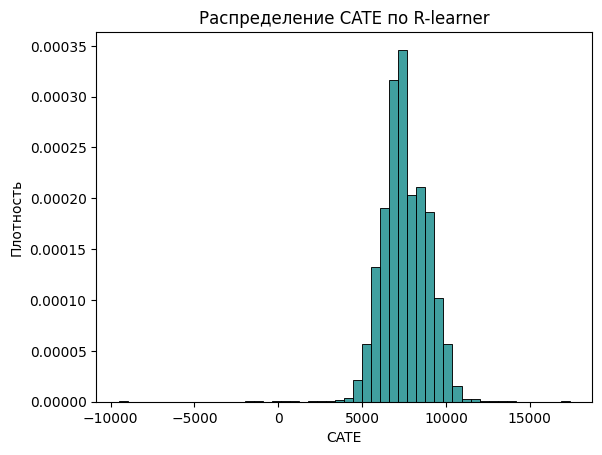

In [108]:
seaborn.histplot(CATE_R, stat = 'density', bins = 50, color = 'teal')
plt.xlabel('CATE')
plt.ylabel('Плотность')
plt.title('Распределение CATE по R-learner')
plt.show()

In [109]:
CATE_quality = pd.DataFrame({
    'mean CATE': [np.mean(CATE_ls), np.mean(CATE_T), np.mean(CATE_S), np.mean(CATE_CT), np.mean(CATE_X), np.mean(CATE_R)],
    'bias mean': [np.mean(CATE_ls) - ATE, np.mean(CATE_T) - ATE, np.mean(CATE_S) - ATE,
                  np.mean(CATE_CT) - ATE, np.mean(CATE_X) - ATE, np.mean(CATE_R) - ATE],
    'RMSE': [np.sqrt(np.mean((CATE_ls - CATE) ** 2)), np.sqrt(np.mean((CATE_T - CATE) ** 2)),
             np.sqrt(np.mean((CATE_S - CATE) ** 2)), np.sqrt(np.mean((CATE_CT - CATE) ** 2)),
             np.sqrt(np.mean((CATE_X - CATE) ** 2)), np.sqrt(np.mean((CATE_R - CATE) ** 2))],
    'MAE': [np.mean(np.abs(CATE_ls - CATE)), np.mean(np.abs(CATE_T - CATE)),
            np.mean(np.abs(CATE_S - CATE)), np.mean(np.abs(CATE_CT - CATE)),
            np.mean(np.abs(CATE_X - CATE)), np.mean(np.abs(CATE_R - CATE))],
    'corr with true CATE': [np.corrcoef(CATE_ls, CATE)[0, 1], np.corrcoef(CATE_T, CATE)[0, 1],
                             np.corrcoef(CATE_S, CATE)[0, 1], np.corrcoef(CATE_CT, CATE)[0, 1],
                             np.corrcoef(CATE_X, CATE)[0, 1], np.corrcoef(CATE_R, CATE)[0, 1]]
}, index = ['LS', 'T-learner', 'S-learner', 'CT', 'X-learner', 'R-learner'])

CATE_MSE0 = pd.DataFrame({'MSE0': CATE_quality['RMSE'] ** 2})
print(CATE_quality)

             mean CATE    bias mean         RMSE          MAE  \
LS         8034.566740  1741.606266  2588.920971  2119.934038   
T-learner  7841.204849  1548.244374  2503.749611  2023.976729   
S-learner  7785.133587  1492.173112  2450.863404  1989.368169   
CT         7816.842115  1523.881640  3691.492248  2529.430633   
X-learner  7757.370524  1464.410049  2434.239929  1968.288280   
R-learner  7582.083415  1289.122940  2431.147547  1943.286888   

           corr with true CATE  
LS                    0.617022  
T-learner             0.587999  
S-learner             0.604093  
CT                    0.409563  
X-learner             0.604059  
R-learner             0.529921  


## 5.6 Оценка LATE

In [110]:
dml_no_iv_data = dml.DoubleMLData(data   = df,
                                  y_col  = 'monthly_spending',
                                  d_cols = 'premium_subscription',
                                  x_cols = controls)

np.random.seed(123)
dml_no_iv = dml.DoubleMLIRM(obj_dml_data = dml_no_iv_data,
                            ml_g         = g_Y,
                            ml_m         = g_T,
                            n_rep        = 1,
                            n_folds      = 5)

dml_no_iv.fit()
ATE_dml_no_iv = dml_no_iv.coef[0]
print(dml_no_iv)

================== DoubleMLIRM Object ==================

------------------ Data Summary      ------------------
Outcome variable: monthly_spending
Treatment variable(s): ['premium_subscription']
Covariates: ['income', 'age', 'urban_area', 'family_size']
Instrument variable(s): None
No. Observations: 10000

------------------ Score & Algorithm ------------------
Score function: ATE

------------------ Machine Learner   ------------------
Learner ml_g: GradientBoostingRegressor(n_estimators=120, random_state=123)
Learner ml_m: GradientBoostingClassifier(max_depth=2, random_state=123)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[2236.91954694]]
Learner ml_g1 RMSE: [[4115.61462301]]
Classification:
Learner ml_m Log Loss: [[0.5880917]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sample splits: 1

------------------ Fit Summary       ------------------
                             coef    std err           t  P>|t|        2.5 %  \
prem

In [111]:
dml_iv_data = dml.DoubleMLData(data   = df,
                               y_col  = 'monthly_spending',
                               d_cols = 'premium_subscription',
                               z_cols = 'free_trial_banner',
                               x_cols = controls)

g_Z = GradientBoostingClassifier(loss          = 'log_loss',
                                 n_estimators  = 100,
                                 learning_rate = 0.1,
                                 random_state  = 123)

np.random.seed(123)
dml_iv = dml.DoubleMLIIVM(obj_dml_data = dml_iv_data,
                          ml_g         = g_Y,
                          ml_m         = g_Z,
                          ml_r         = g_T,
                          n_rep        = 1,
                          n_folds      = 5)

dml_iv.fit()
LATE_dml_iv = dml_iv.coef[0]
print(dml_iv)

================== DoubleMLIIVM Object ==================

------------------ Data Summary      ------------------
Outcome variable: monthly_spending
Treatment variable(s): ['premium_subscription']
Covariates: ['income', 'age', 'urban_area', 'family_size']
Instrument variable(s): ['free_trial_banner']
No. Observations: 10000

------------------ Score & Algorithm ------------------
Score function: LATE

------------------ Machine Learner   ------------------
Learner ml_g: GradientBoostingRegressor(n_estimators=120, random_state=123)
Learner ml_m: GradientBoostingClassifier(random_state=123)
Learner ml_r: GradientBoostingClassifier(max_depth=2, random_state=123)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[4745.69023845]]
Learner ml_g1 RMSE: [[4938.0615393]]
Classification:
Learner ml_m Log Loss: [[0.52915578]]
Learner ml_r0 Log Loss: [[0.58673924]]
Learner ml_r1 Log Loss: [[0.5665024]]

------------------ Resampling        ------------------
No. folds: 5
No. repeated sam

In [112]:
selection_x = sm.add_constant(df.loc[:, ['free_trial_banner'] + controls])
selection_model = sm.Probit(df['premium_subscription'], selection_x).fit(disp = False)
selection_index = np.asarray(selection_model.predict(selection_x, which = "linear"))
selection_prob = np.clip(np.asarray(selection_model.predict(selection_x)), 1e-6, 1 - 1e-6)

mills_treated = norm.pdf(selection_index) / selection_prob
mills_control = -norm.pdf(selection_index) / (1 - selection_prob)

outcome_x = sm.add_constant(df.loc[:, controls])
outcome_treated_x = outcome_x.loc[premium_subscription == 1].copy()
outcome_control_x = outcome_x.loc[premium_subscription == 0].copy()
outcome_treated_x['mills'] = mills_treated[premium_subscription == 1]
outcome_control_x['mills'] = mills_control[premium_subscription == 0]

switch_y1_model = sm.OLS(df.loc[premium_subscription == 1, 'monthly_spending'], outcome_treated_x).fit()
switch_y0_model = sm.OLS(df.loc[premium_subscription == 0, 'monthly_spending'], outcome_control_x).fit()

outcome_all_treated = outcome_x.copy()
outcome_all_control = outcome_x.copy()
outcome_all_treated['mills'] = mills_treated
outcome_all_control['mills'] = mills_control

monthly_spending1_switch = np.asarray(switch_y1_model.predict(outcome_all_treated))
monthly_spending0_switch = np.asarray(switch_y0_model.predict(outcome_all_control))
tau_switch = monthly_spending1_switch - monthly_spending0_switch

selection_z1 = selection_x.copy()
selection_z0 = selection_x.copy()
selection_z1['free_trial_banner'] = 1
selection_z0['free_trial_banner'] = 0
p_t1_z1 = np.clip(np.asarray(selection_model.predict(selection_z1)), 1e-6, 1 - 1e-6)
p_t1_z0 = np.clip(np.asarray(selection_model.predict(selection_z0)), 1e-6, 1 - 1e-6)
complier_weight_raw = p_t1_z1 - p_t1_z0
complier_weight = np.clip(complier_weight_raw, a_min = 0, a_max = None)

weight_mask = complier_weight > 1e-6
LATE_switch = np.average(tau_switch[weight_mask], weights = complier_weight[weight_mask])
LATE_switch_abs_gap = np.abs(LATE_switch - LATE)

switch_diagnostics = pd.DataFrame(data    = [
                                    np.mean(complier_weight_raw < 0),
                                    np.mean(complier_weight <= 1e-6),
                                    np.mean(complier_weight_raw),
                                    np.mean(complier_weight),
                                    np.sum(complier_weight),
                                    LATE_switch,
                                    LATE_switch_abs_gap],
                                 index   = ['share negative raw complier weights',
                                            'share clipped or near-zero weights',
                                            'mean raw complier weight',
                                            'mean clipped complier weight',
                                            'sum clipped complier weights',
                                            'LATE parametric switching',
                                            '|parametric switching - true LATE|'],
                                 columns = ['Оценка'])
print(switch_diagnostics)

                                          Оценка
share negative raw complier weights     0.000000
share clipped or near-zero weights      0.000000
mean raw complier weight                0.160194
mean clipped complier weight            0.160194
sum clipped complier weights         1601.938869
LATE parametric switching            8027.336694
|parametric switching - true LATE|   1747.017537


In [113]:
LATE_table = pd.DataFrame({
    'Оценка': [ATE, LATE, ATE_dml_no_iv, LATE_dml_iv, LATE_switch],
    '|estimate - true LATE|': [np.abs(ATE - LATE), 0, np.abs(ATE_dml_no_iv - LATE),
                              np.abs(LATE_dml_iv - LATE), LATE_switch_abs_gap]
}, index = ['ATE', 'LATE', 'ATE dml no IV', 'LATE dml IV', 'LATE parametric switching'])
print(LATE_table)

                                Оценка  |estimate - true LATE|
ATE                        6292.960475               12.641317
LATE                       6280.319157                0.000000
ATE dml no IV              7810.003445             1529.684288
LATE dml IV                6250.160365               30.158792
LATE parametric switching  8027.336694             1747.017537


## 5.7 Устойчивость к качеству моделей

In [114]:
worst_classification = clone(all_classification_models[worst_model])
worst_classification.fit(features, np.ravel(target))

worst_regression = clone(worst_regressor_all)
worst_regression.fit(features, np.ravel(y))

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [115]:
rf = clone(worst_regression)

x0_worst = df.loc[premium_subscription == 0, controls]
x1_worst = df.loc[premium_subscription == 1, controls]
x_worst  = df.loc[:, controls]

rf.fit(x0_worst, np.ravel(y0))
monthly_spending0_worst = rf.predict(x_worst)

rf.fit(x1_worst, np.ravel(y1))
monthly_spending1_worst = rf.predict(x_worst)

CATE_T_worst = monthly_spending1_worst - monthly_spending0_worst
ATE_T_worst = np.mean(CATE_T_worst)
ATE_ls_worst = np.mean(monthly_spending1_worst - monthly_spending0_worst)

gb = clone(worst_classification)
gb.fit(features, np.ravel(target))
prob_gb_worst = gb.predict_proba(features)[:, 1]
print(pd.DataFrame(data    = [np.min(prob_gb_worst), np.max(prob_gb_worst)],
                   index   = ['worst min prob', 'worst max prob'],
                   columns = ['Оценка']))

monthly_spending_pseudo_worst = ((monthly_spending * premium_subscription) / prob_gb_worst -
                                 (monthly_spending * (1 - premium_subscription)) / (1 - prob_gb_worst))
ATE_IPW_worst = np.mean(monthly_spending_pseudo_worst)

ATE_DR_worst = np.mean((monthly_spending1_worst - monthly_spending0_worst) +
                       premium_subscription * (monthly_spending - monthly_spending1_worst) / prob_gb_worst -
                       (1 - premium_subscription) * (monthly_spending - monthly_spending0_worst) / (1 - prob_gb_worst))

                  Оценка
worst min prob  0.073396
worst max prob  0.991612


In [116]:
dml_worst_data = dml.DoubleMLData(data   = df,
                                  y_col  = 'monthly_spending',
                                  d_cols = 'premium_subscription',
                                  x_cols = controls)

g_Y_worst = clone(worst_regression)
g_T_worst = clone(worst_classification)

np.random.seed(123)
dml_worst = dml.DoubleMLIRM(obj_dml_data = dml_worst_data,
                            ml_g         = g_Y_worst,
                            ml_m         = g_T_worst,
                            n_rep        = 1,
                            n_folds      = 5)

dml_worst.fit()
ATE_dml_worst = dml_worst.coef[0]

dml_iv_worst_data = dml.DoubleMLData(data   = df,
                                     y_col  = 'monthly_spending',
                                     d_cols = 'premium_subscription',
                                     z_cols = 'free_trial_banner',
                                     x_cols = controls)

g_Z_worst = clone(worst_classification)

np.random.seed(123)
dml_iv_worst = dml.DoubleMLIIVM(obj_dml_data = dml_iv_worst_data,
                                ml_g         = g_Y_worst,
                                ml_m         = g_Z_worst,
                                ml_r         = g_T_worst,
                                n_rep        = 1,
                                n_folds      = 5)

dml_iv_worst.fit()
LATE_dml_iv_worst = dml_iv_worst.coef[0]

In [117]:
stability_table = pd.DataFrame({
    'лучшие модели': [ATE_ls, ATE_T, ATE_IPW, ATE_DR, ATE_dml_standard, LATE_dml_iv],
    'худшие модели': [ATE_ls_worst, ATE_T_worst, ATE_IPW_worst, ATE_DR_worst, ATE_dml_worst, LATE_dml_iv_worst]
}, index = ['ATE ls', 'ATE conditional means', 'ATE IPW', 'ATE DR', 'ATE DML', 'LATE DML IV'])
print(stability_table)

                       лучшие модели  худшие модели
ATE ls                   8034.566740    8034.566740
ATE conditional means    7841.204849    8034.566740
ATE IPW                  7816.842115    7984.611865
ATE DR                   7820.110448    8059.480670
ATE DML                  7810.003445    8057.230717
LATE DML IV              6250.160365    8091.453843


## 5.8 Резюме

In [118]:
print('ATE:')
print(ATE_table_best)
print('\nCATE MSE:')
print(CATE_MSE0)
print('\nLATE:')
print(LATE_table)
print('\nУстойчивость:')
print(stability_table)

ATE:
                            Оценка
ATE                    6292.960475
ATE naive              9883.189426
ATE ls                 8034.566740
ATE conditional means  7841.204849
ATE dml standard       7810.003445
ATE IPW                7816.842115
ATE DR                 7820.110448
ATE PSM                8019.055227

CATE MSE:
                   MSE0
LS         6.702512e+06
T-learner  6.268762e+06
S-learner  6.006731e+06
CT         1.362712e+07
X-learner  5.925524e+06
R-learner  5.910478e+06

LATE:
                                Оценка  |estimate - true LATE|
ATE                        6292.960475               12.641317
LATE                       6280.319157                0.000000
ATE dml no IV              7810.003445             1529.684288
LATE dml IV                6250.160365               30.158792
LATE parametric switching  8027.336694             1747.017537

Устойчивость:
                       лучшие модели  худшие модели
ATE ls                   8034.566740    8034.5667